# Exercise 2: KSW SOLUTION: Investigate model performance bottlenecks with PyTorch Profiler

You have explored hardware platforms, performance metrics, and hardware-first thinking in theory. It is now time to move from understanding concepts to hands-on diagnosis, and systematically investigate real model performance bottlenecks using professional profiling tools.

> **Overview:** A fintech company's customer churn prediction model (a multi-layer perceptron processing transaction features) is causing API timeouts in production. Use PyTorch Profiler's multiple analysis modes to diagnose performance issues and identify optimization opportunities on your GPU.
> 
> **Scenario:** You work for a fintech startup that predicts customer churn to trigger retention campaigns. Your ML team deployed a neural network that processes customer transaction features to predict churn probability. In development on your local machine, individual predictions ran smoothly, but when deployed to production with realistic API loads and batch processing, your DevOps team reports inconsistent performance that's causing service level agreement violations.
> 
> Your DevOps team reports the production servers use NVIDIA T4 GPUs (same as your development environment), but something about the production workload is causing severe performance degradation. You need to systematically profile the model to identify what's limiting throughput and causing the performance variability.
> 
> **Goal**: Learn to use PyTorch Profiler's timeline analysis, memory profiling, and GPU utilization monitoring to systematically diagnose performance bottlenecks and identify hardware-specific optimization opportunities in production AI deployments.
> 
> **Tools**: PyTorch, PyTorch Profiler, pynvml, pandas
> 
> **Estimated Time**: 15 minutes

## KSW NOTES:
## 🎯 What does this code do ?
- DATASET: Downloads a simple csv dataset. Preprocesses it. see readme for preprocessing details
- MODEL: Sets up an inefficient network: see readme for ways that make a neural network inefficient
  
------------------------------------------------------------------------------------------
ANALYSIS TOOLS
- 1) INFERENCE TIME: Measure the inference time
- 2) PYNVML: HARDWARE PROFILING . See readme for various functions explanations
    - get gpu stats before inference
    - get gpu stats after inference
    - calculate the delta gpu stats during inference
- 3) PYTORCH MODEL PROFILING: use pytorch profiler. Sort the prof.key_averages table
  - sorted by cpu time, memory. gpu time, memory. total number of calls to sth
  - sorted by layers. cumulative cpu time and memory, gpu time and memory for each layer
- 4) TENSORBOARD TRACE : do this using pytorch profiler for different batch sizes
- 5) MEMORY PROFILE: export memory profile 
- 6a) TABULATE : prof key averages tables well using pandas data frame to read it better
- 6b) VISUALIZE: visualize the results from prof key averages
------------------------------------------------------------------------------------------

ANALYSE AND UNDERSTAND: Use all the tools above to correctly identify what are the pain points


## HOW TO OPEN TENSORBOARD

Once the logs have been generated. 
- In a new terminal activate the environment in which the notebook was run (yes every new terminal requires the virutal environment)
- change to the directory with the logs
- run tensorboard
- open tensor board from the browser from this link: http://localhost:6006/ sometimes the link local host port could be different. just check the tensorboard messages on the terminal
-  additionally check memory timeline inside the logs. memory_timeline.html. there is 1 for each batch size
```
source ksw/bin/activate

cd udc-ml-model-optimize-nanodeg/c3_efficient_architecture/lesson1_intro_hardware_aware_model_optimization/exercises/ksw_solutionsw/bin/activate

tensorboard --logdir=./logs
# now open this in a browser: http://localhost:6006/
# additionally check memory timeline inside the logs. memory_timeline.html
```


## Step 1: Setup

Let's start by setting up our profiling environment.

In [1]:
# # Uncomment to install necessary libraries, then comment out the cell block again and restart the notebook
# # ! pip install pynvml kagglehub

In [2]:
# Import core libraries
import os
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
import torch.profiler
from torch.utils.data import DataLoader, TensorDataset
from torch.profiler import tensorboard_trace_handler

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pynvml
import time
from datetime import datetime
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Create output directory
output_dir = "assets/exercise2"
os.makedirs(output_dir, exist_ok=True)

## pyvnml

- pynvml is a Python wrapper around NVML (NVIDIA Management Library).
- It allows Python programs to query GPU status without launching tools like nvidia-smi.
- NVML is a C library provided by NVIDIA.The same library is used internally by: nvidia-smi
- nvidia-smi outputs the following. Most of that information comes from NVML.
    - GPU Utilization
    - Memory Usage
    - Temperature
    - Power
    - Clocks

In [3]:
# Initialize NVIDIA management library
pynvml.nvmlInit()
handle = pynvml.nvmlDeviceGetHandleByIndex(0)

# Check GPU availability and get T4 info
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Using GPU: {gpu_name}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("CUDA not available, using CPU")

print("Setup complete!")

Using GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
CUDA Version: 12.4
GPU Memory: 4.1 GB
Setup complete!


## Step 2. Load the dataset

For this exercise, we use the [Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn), hosted in Kaggle.
The raw data contains 7043 rows (customers) and 21 columns (features).

In [4]:
# Download the dataset
df_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df_dirpath = kagglehub.dataset_download("blastchar/telco-customer-churn")
df_path = os.path.join(df_dirpath, df_name)
print("Path to dataset files:", df_path)

Path to dataset files: /home/kssn/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [5]:
print("df_path", df_path)
print("\n")

# Load the dataset
df = pd.read_csv(df_path)

# Get dataset info
print(f"Dataset colums: {list(df.columns)}")
print(df.info)

df_path /home/kssn/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv


Dataset colums: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-R

# Explanation for One Hot Encoding

```
   else:
        # One-hot encoding for multi-class variables
        # takes a categorical column and converts it into multiple binary (0/1) columns. i.e. in line with one hot columns
        dummies = pd.get_dummies(df[col], prefix=col)
        # Take the original dataframe (df) and the dummy dataframe (dummies) and sticks them together side-by-side.
        df = pd.concat([df, dummies], axis=1)
        df.drop(col, axis=1, inplace=True)
```

Original Data Frame
| CustomerID | Contract       |
| ---------- | -------------- |
| 1          | Month-to-month |
| 2          | One year       |
| 3          | Two year       |


Dummy Data Frame
| Contract_Month-to-month | Contract_One year | Contract_Two year |
| ----------------------- | ----------------- | ----------------- |
| 1                       | 0                 | 0                 |
| 0                       | 1                 | 0                 |
| 0                       | 0                 | 1                 |

AFter
df = pd.concat([df, dummies], axis=1)
| CustomerID | Contract       | Contract_Month-to-month | Contract_One year | Contract_Two year |
| ---------- | -------------- | ----------------------- | ----------------- | ----------------- |
| 1          | Month-to-month | 1                       | 0                 | 0                 |
| 2          | One year       | 0                       | 1                 | 0                 |
| 3          | Two year       | 0                       | 0                 | 1                 |

After Dropping
df.drop("Contract", axis=1, inplace=True)
| CustomerID | Contract_Month-to-month | Contract_One year | Contract_Two year |
| ---------- | ----------------------- | ----------------- | ----------------- |
| 1          | 1                       | 0                 | 0                 |
| 2          | 0                       | 1                 | 0                 |
| 3          | 0                       | 0                 | 1                 |


so after all the preprocessing it would look like this
- those columns with only 2 unique values, or 2+ no phone service will have 0/1
- rest of the columns with 3 or more values have been converted to one hot encoding.
    - example contract with 3 values (month to month contract, one year contract, two year contract) with the Labelencoder would have has values 0,1,2,. But the model might learn erroneously 0<1<2, i.e month to month contract is somehow numerically lessert han one year contract. But the value are qualitative the numbers have no bearing. Hence one hot encoding has been adopted
    - with one hot encoding one single contract column with 1 of 3 possible values has become 3 columns. contract_month_to_mont, contract_one_year, contract_two_year
- IMO / In Krithika's Opinion this is a mess. Some columns are binary values. some are one hot encoded. everthing should be one hot encoded imo
                | Feature       | Encoding          |
                | ------------- | ----------------- |
                | gender        | 0/1               |
                | Partner       | 0/1               |
                | Dependents    | 0/1               |
                | Contract      | 3 one-hot columns |
                | PaymentMethod | 4 one-hot columns |



In [6]:
# Preprocess dataset
# Data preprocessing for the real dataset
print("\nPreprocessing the dataset...")

# Handle TotalCharges column (contains some string values that need conversion)
# TotalCharges should be numeric, but it may contain strings like "123.45" or blank values.
# This converts valid values to numbers. Invalid values become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# fillna() is a Pandas function that replaces missing values (NaN) with something else.
# This replaces missing values with the median TotalCharges.
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode categorical variables
categorical_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                      'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                      'PaperlessBilling', 'PaymentMethod']

# Use LabelEncoder for binary categorical variables and get_dummies for multi-class
# This code converts categorical (text) features into numeric features so that a machine learning model can use them.
label_encoders = {}
for col in categorical_columns:
    # nunique() returns the number of unique values in the column. It only counts the numberof unique values. 
    # It doesnt return the actual values like "male" or "female"
    # If there are only 2 categories, or there are 3 categories one of which is 'No Phone service'. 
    # Example: 'Yes', 'No', 'No Phone Service'. Then No phone service would also get encoded as 'No'
    
    if df[col].nunique() == 2 or (df[col].nunique() == 3 and 'No phone service' in df[col].values):
        # Binary encoding for simple categorical variables
        # LabelEncoder finds all unique categories and assigns integers.(beginning with 0)
        # So the unique values are identified twice, once with nunique and once with LabelEncoder ???
        # nunique returns only the count. LabelEncoder finds the actual values, like Male, Female. Sorts them and assigns integers
        le = LabelEncoder()
        # This modifies the dataframe column to have 0,1, etc instead of Female, Male
        df[col] = le.fit_transform(df[col])
        # The stores the label encoder mappings
        # So this becomes label_encoders = {"gender": le } &  le is the encoder that learnt Female -> 0, Male   -> 1
        label_encoders[col] = le
    else:
        # One-hot encoding for multi-class variables
        # takes a categorical column and converts it into multiple binary (0/1) columns. i.e. in line with one hot columns
        dummies = pd.get_dummies(df[col], prefix=col)
        # Take the original dataframe (df) and the dummy dataframe (dummies) and sticks them together side-by-side.
        df = pd.concat([df, dummies], axis=1)
        df.drop(col, axis=1, inplace=True)

# Encode target variable
# in the 'Churn' column replaces 'Yes' with 1 & 'No'with 0}
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID as it's just an identifier
df.drop('customerID', axis=1, inplace=True)

# Prepare features and target
feature_columns = [col for col in df.columns if col != 'Churn']
X = df[feature_columns].values
y = df['Churn'].values

print(f"\nFinal dataset info:")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Churn rate: {y.mean():.1%}")
print(f"Number of features after encoding: {len(feature_columns)}")

# Display first few feature names for reference
print(f"\nFeature Columns: {feature_columns}")


Preprocessing the dataset...

Final dataset info:
Features shape: (7043, 38)
Target shape: (7043,)
Churn rate: 26.5%
Number of features after encoding: 38

Feature Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Cr

> **Dataset insights**: The Telco dataset contains 7,043 customers with 21 features covering demographics, services, and billing information. 
> 
> After preprocessing categorical variables (gender, contract types, internet services, etc.), we end up with 38 features given one-hot encoding. 
> 
> The 26.5% churn rate provides a realistic class imbalance that mirrors production scenarios. 

In [7]:
# Prepare features and target
# 'churn'  column is the label, rest of the columns are features. (so they are multidimensional features)
label_col = 'Churn'
feature_columns = [col for col in df.columns if col != label_col]
X = df[feature_columns].values
y = df[label_col].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

print(f"Training data shape: {X_train_tensor.shape}")
print(f"Test data shape: {X_test_tensor.shape}")

Training data shape: torch.Size([5634, 38])
Test data shape: torch.Size([1409, 38])


## Step 3: Create the "problematic" model architecture
Let's create a neural network with intentional inefficiencies that mirror common real-world performance issues.

In [8]:
class ProblematicChurnModel(nn.Module):
    """
    A deliberately inefficient model architecture that creates realistic bottlenecks
    on T4 GPUs. This simulates common mistakes in production deployments.
    """
    def __init__(self, input_size, hidden_sizes=[512, 1024, 512, 256, 128]):
        super(ProblematicChurnModel, self).__init__()
        
        # Inefficient architecture choices that will show up in profiling:
        
        # 1. Oversized hidden layers for the problem complexity
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            # 2. Using individual Linear layers instead of Sequential blocks
            '''
            KSW comment: 
            i) it is using nn.sequential(*layers) a few lines below. So i'm not sure why it is inefficient
            ii)  linear-> Relu-> Dropout is the standard. not sure what is wrong with the dropout placement either
            iii) as per ksw the fully connected layers and the number of them is an overkill for a csv. 
            that is the pain point really
            # number of parameters
            i) input_size* 512: [input_size]*512
            ii)   512*1024 = 524288 parameters
            iii) 1024*512  = 524288 parameters
            iv)   512*256  = 131072 parameters
            v)    256*128  =  32768 parameters
            Total Parameters ~= 1.2 Million + [input_size]*512 atleast
            
            chatgpt seems to independently agree with me ! LOL !
            as per chatgpt maybe they meant use sequential like below. so you have clear blocks
            block = nn.Sequential(
                     nn.Linear(prev_size, hidden_size),
                     nn.ReLU(),
                     nn.Dropout(0.3)
                    )
            This makes it more organized, but not necessarily faster
            '''
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            # 3. Inefficient dropout placement (will cause extra memory operations)
            layers.append(nn.Dropout(0.3))
            prev_size = hidden_size
        
        # 4. Output layer
        layers.append(nn.Linear(prev_size, 1))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
        
        # 5. Inefficient custom forward pass that will show up in profiling
        self.custom_activation = nn.ReLU()
        
    def forward(self, x):
        
        # 6. Inefficient forward pass with unnecessary operations
       
        batch_size = x.size(0)        
        # Extra tensor operations that fragment GPU utilization
        x = x + 0.0001  # Unnecessary operation that creates new tensor
        x = x * 1.0001  # Another unnecessary operation
        
        # Pass through main network
        x = self.network(x)
        
        # 7. Inefficient final processing
        # Force CPU-GPU sync (performance killer!)
        if batch_size > 1:
            # This creates a CPU-GPU synchronization point
            # This is the absolute worst.
            # x is on the GPU. torch.mean(x) computes a GPU tensor. But .item() asks Python on the CPU to get the scalar value
            # the final variable mean_activation lives on the CPU. It is a CPU-side Python scalar.
            mean_activation = torch.mean(x).item()  # .item() forces sync!
            
        return x

In [9]:
# TODO: Create the model on GPU
# Hint: Review https://discuss.pytorch.org/t/is-there-any-difference-between-x-to-cuda-vs-x-cuda-which-one-should-i-use/20137
# for information on how to move a model to cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = X_train.shape[1]   # number of CSV/tabular input features
model = ProblematicChurnModel(input_size=input_size).to(device)

print(f"Using device: {device}")
print("Model architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Model architecture:
ProblematicChurnModel(
  (network): Sequential(
    (0): Linear(in_features=38, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=1024, out_features=512, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=512, out_features=256, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=128, out_features=1, bias=True)
    (16): Sigmoid()
  )
  (custom_activation): ReLU()
)

Total parameters: 1,234,433


> **Architecture analysis**: Notice the deliberately problematic choices:
> 
> - Oversized layers (1024 units for simple tabular data)
> - Inefficient forward pass with unnecessary tensor operations
> - CPU-GPU synchronization points that will show up clearly in profiling
> - Dropout in inference mode (though PyTorch optimizes this out)

## Step 4: Establish baseline model performance

### Step 4a: Train the Baseline Model: Train Datasets
Let's train now our baseline model to measure baseline performance.

In [10]:
# Train the problematic model
print("Training the problematic model...")

# Setup training
# BCE : Binary Cross entropy Loss. Used for binary classification problems
criterion = nn.BCELoss()
# Adam optimizer for updating the weights during back propagation
optimizer = optim.Adam(model.parameters(), lr=0.001)
# The dataloader can only deal with a dataset object. The TensorDataset makes it a dataset object
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Training loop (keep it short for the exercise)
model.train()
for epoch in range(5):  # Quick training, just enough to get reasonable weights
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data).squeeze()
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if epoch % 2 == 0:
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/5, Average Loss: {avg_loss:.4f}")

print("Training complete!")

Training the problematic model...
Epoch 1/5, Average Loss: 0.4680
Epoch 3/5, Average Loss: 0.4257
Epoch 5/5, Average Loss: 0.4274
Training complete!


> **Note on model accuracy**: Since this exercise focuses on performance profiling, we skip evaluating model accuracy. Our goal is to diagnose why that model runs slowly during inference, regardless of how well it predicts churn.
> 
> In production, you'd have a well-trained model that meets your accuracy requirements. Feel free to extend this exercise by adding validation accuracy tracking, confusion matrix analysis, or ROC curve evaluation if you want to explore the trade-offs between model performance optimization and predictive accuracy!

### Step 4b: Measure Baseline Model Performance (without profiling): Test Dataset
Measure the time for inference

In [11]:
## Create DataLoaders with different batch sizes to simulate production scenarios
batch_sizes = [32, 64, 128, 512, 1024,2048,4096]  # We'll test different batch sizes
test_dataloaders = {}

for batch_size in batch_sizes:
    # KSW comment: Dataset should be outside the loop
    dataset = TensorDataset(X_test_tensor, y_test_tensor)
    test_dataloaders[batch_size] = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
print(f"Created DataLoaders for batch sizes: {batch_sizes}")

Created DataLoaders for batch sizes: [32, 64, 128, 512, 1024, 2048, 4096]


In [12]:
# Measure baseline performance without profiling
def measure_baseline_performance(model, dataloader, num_batches=10):
    """Measure baseline inference performance"""
            
    model.eval()
    times = []

    # TODO: Measure inference times on first few batches
    # Hint: Use torch.cuda.synchronize() before and after inference, then measure time with time.perf_counter()
    # Don't forget to break the loop after num_batches has been achieved

    # KSW Code
    device = next(model.parameters()).device

    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(dataloader):
            if batch_idx >= num_batches:
                break

            data = data.to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()

            start_time = time.perf_counter()

            output = model(data)

            if device.type == "cuda":
                torch.cuda.synchronize()

            end_time = time.perf_counter()

            times.append(end_time - start_time)

    return times

## Start measurement wifferent batch sizes
baseline_results = {}
print("Measuring baseline performance...")

for batch_size in batch_sizes:
    times = measure_baseline_performance(model, test_dataloaders[batch_size])
    avg_time = np.mean(times) * 1000  # Convert to milliseconds
    baseline_results[batch_size] = {
        'avg_time_ms': avg_time,
        'std_time_ms': np.std(times) * 1000,
        'times': times
    }
    print(f"Batch size {batch_size}: {avg_time:.2f} ± {baseline_results[batch_size]['std_time_ms']:.2f} ms")


Measuring baseline performance...
Batch size 32: 0.24 ± 0.10 ms
Batch size 64: 0.17 ± 0.01 ms
Batch size 128: 0.23 ± 0.03 ms
Batch size 512: 0.58 ± 0.13 ms
Batch size 1024: 0.69 ± 0.23 ms
Batch size 2048: 1.06 ± 0.00 ms
Batch size 4096: 1.04 ± 0.00 ms


> **Batch size optimization insight**: Notice that it is not the larger batch size to achieve better performance This is because:
> 
> - **With too small batches**: GPU cores underutilized, overhead from frequent kernel launches
> - **With optimal batch**: Good GPU utilization without memory pressure 
> - **With too large batches**: Memory bandwidth saturation and increased variance
> 
> This "sweet spot" pattern is common in production - optimal batch size balances GPU utilization with memory efficiency.

## Step 5: GPU system monitoring with pynvml
Before diving into detailed profiling, let's establish our hardware baseline using NVIDIA's system monitoring.
See the readme for details on the pynvml functions

In [13]:
# Create functions to monitor GPU utilization and memory usage

def get_gpu_stats():
    """Get current GPU utilization and memory usage"""
    # TODO: Get utilization rates (GPU and memory) using pynvml
    # Hint: Find a complete list of methods at https://docs.nvidia.com/deploy/nvml-api/nvml-api-reference.html
    # You can use the `handle` previously created
    # Add your code here
    # KSW Code
    util = pynvml.nvmlDeviceGetUtilizationRates(handle)
    memory = pynvml.nvmlDeviceGetMemoryInfo(handle)

    graphics_clock = pynvml.nvmlDeviceGetClockInfo(handle, pynvml.NVML_CLOCK_GRAPHICS)
    memory_clock = pynvml.nvmlDeviceGetClockInfo(handle, pynvml.NVML_CLOCK_MEM)
    
    temp = pynvml.nvmlDeviceGetTemperature(handle, pynvml.NVML_TEMPERATURE_GPU)
    power_usage = pynvml.nvmlDeviceGetPowerUsage(handle) / 1000.0
    power_limit = pynvml.nvmlDeviceGetEnforcedPowerLimit(handle) / 1000.0

    perf_state = pynvml.nvmlDeviceGetPerformanceState(handle)
    throttle_reasons = pynvml.nvmlDeviceGetCurrentClocksThrottleReasons(handle)    
    
    return {
        # Basic utilization
        'gpu_util': util.gpu,
        'memory_util': util.memory,
        'memory_used_mb': memory.used / 1024**2,
        'memory_total_mb': memory.total / 1024**2,
        'memory_free_mb': memory.free / 1024**2,
        
        # Performance monitoring
        'graphics_clock_mhz': graphics_clock,
        'memory_clock_mhz': memory_clock,
        'performance_state': perf_state,
        'is_throttling': throttle_reasons != 0,
        'throttle_reasons': throttle_reasons,

        # Thermal and power
        'temperature_c': temp,
        'power_usage_w': power_usage,
        'power_limit_w': power_limit,
        'power_efficiency': util.gpu / max(power_usage, 1),  # GPU util per watt
    }


def monitor_inference_workload(model, dataloader, duration_seconds=10):
    """
        Monitor GPU stats during inference workload
        This function returns the stats
        - before inference : get_gpu_stats
        - after inference : get_gpu_stats
        - calculates the delta during the inference 
    """
    
    model.eval()
    stats_history = []

    # Add debugging to ensure we're actually using GPU
    print(f"Model device: {next(model.parameters()).device}")
    print(f"Input data will be on: {device}")
    
    start_time = time.time()
    batch_count = 0
    
    with torch.no_grad():
        while time.time() - start_time < duration_seconds:
            for inputs, _ in dataloader:
                # Record stats before inference
                stats_before = get_gpu_stats()
                
                # TODO: Run inference
                # Hint: Remember to synchronize, and add a small delay to ensure GPU work is captured
                # KSW Code
                inputs = inputs.to(device, non_blocking=True)

                if device.type == "cuda":
                    torch.cuda.synchronize()

                # Run inference
                outputs = model(inputs)
                
                if device.type == "cuda":
                    torch.cuda.synchronize()
                
                time.sleep(0.01)
                
                # Record stats after inference
                stats_after = get_gpu_stats()
                
                stats_history.append({
                    'batch': batch_count,
                    'timestamp': time.time() - start_time,     
                    'batch_size': inputs.shape[0],

                    # Before inference
                    'gpu_util_before': stats_before['gpu_util'],
                    'memory_used_before_mb': stats_before['memory_used_mb'],
                    'temp_before_c': stats_before['temperature_c'],
                    'power_before_w': stats_before['power_usage_w'],
                    
                    # After inference  
                    'gpu_util_after': stats_after['gpu_util'],
                    'memory_used_after_mb': stats_after['memory_used_mb'],
                    'temp_after_c': stats_after['temperature_c'],
                    'power_after_w': stats_after['power_usage_w'],
                    
                    # Derived metrics
                    'gpu_util_delta': stats_after['gpu_util'] - stats_before['gpu_util'],
                    'memory_delta_mb': stats_after['memory_used_mb'] - stats_before['memory_used_mb'],
                    'temp_delta_c': stats_after['temperature_c'] - stats_before['temperature_c'],
                    'power_delta_w': stats_after['power_usage_w'] - stats_before['power_usage_w'],
                    
                    # Hardware state
                    'is_throttling': stats_after['is_throttling'],
                    'performance_state': stats_after['performance_state']
                })
                
                batch_count += 1
                
                if time.time() - start_time >= duration_seconds:
                    break
    
    return stats_history

In [14]:
# Run monitoring for batch size 64 and analyze the results
print("Monitoring GPU utilization during inference...")
stats = monitor_inference_workload(model, test_dataloaders[512], duration_seconds=8)

# Analyze the monitoring results
gpu_utils_after    = [s['gpu_util_after'] for s in stats]  
temps_after        = [s['temp_after_c'] for s in stats]
power_usage_after  = [s['power_after_w'] for s in stats]
memory_usage_after = [s['memory_used_after_mb'] for s in stats]
throttling_events  = [s for s in stats if s['is_throttling']]

# Calculate power efficiency
power_efficiency = [gpu_util / max(power, 1) for gpu_util, power in zip(gpu_utils_after, power_usage_after)]

print(f"\n=== COMPREHENSIVE GPU ANALYSIS ===")
print(f"Average GPU utilization: {np.mean(gpu_utils_after):.1f}%")
print(f"Peak GPU utilization: {np.max(gpu_utils_after):.1f}%")
print(f"GPU utilization std dev: {np.std(gpu_utils_after):.1f}%")
print(f"Temperature range: {np.min(temps_after):.1f}°C - {np.max(temps_after):.1f}°C")
print(f"Power usage range: {np.min(power_usage_after):.1f}W - {np.max(power_usage_after):.1f}W")
print(f"Average power efficiency: {np.mean(power_efficiency):.2f} util%/W")
print(f"Average memory usage: {np.mean(memory_usage_after):.1f} MB")
print(f"Performance state (P0=max): P{stats[0]['performance_state']}")

if throttling_events:
    print(f"WARNING:  THROTTLING DETECTED: {len(throttling_events)} events out of {len(stats)} batches")
    print("   This could explain performance degradation!")
else:
    print("SUCCESS: No throttling detected during monitoring period")

# Analyze the before/after patterns  
gpu_util_deltas = [s['gpu_util_delta'] for s in stats]
memory_deltas   = [s['memory_delta_mb'] for s in stats]
temp_deltas     = [s['temp_delta_c'] for s in stats]
power_deltas    = [s['power_delta_w'] for s in stats]

print(f"\n=== INFERENCE IMPACT ANALYSIS ===")
print(f"GPU utilization change per batch: {np.mean(gpu_util_deltas):.1f}% ± {np.std(gpu_util_deltas):.1f}%")
print(f"Memory allocation per batch: {np.mean(memory_deltas):.2f} MB ± {np.std(memory_deltas):.2f} MB")
print(f"Temperature increase per batch: {np.mean(temp_deltas):.2f}°C ± {np.std(temp_deltas):.2f}°C") 
print(f"Power consumption change: {np.mean(power_deltas):.1f}W ± {np.std(power_deltas):.1f}W")

print(f"\nProcessed {len(stats)} batches with comprehensive hardware monitoring")

Monitoring GPU utilization during inference...
Model device: cuda:0
Input data will be on: cuda

=== COMPREHENSIVE GPU ANALYSIS ===
Average GPU utilization: 2.9%
Peak GPU utilization: 47.0%
GPU utilization std dev: 9.2%
Temperature range: 50.0°C - 52.0°C
Power usage range: 9.9W - 23.4W
Average power efficiency: 0.17 util%/W
Average memory usage: 381.0 MB
Performance state (P0=max): P0
SUCCESS: No throttling detected during monitoring period

=== INFERENCE IMPACT ANALYSIS ===
GPU utilization change per batch: 0.0% ± 0.2%
Memory allocation per batch: 0.00 MB ± 0.00 MB
Temperature increase per batch: 0.00°C ± 0.00°C
Power consumption change: -0.0W ± 0.2W

Processed 145 batches with comprehensive hardware monitoring


> TODO: Analyze GPU monitoring insights and identify potential issues
> 
> Hint: Focus on GPU utilization patterns and power efficiency metrics. What does extremely low GPU utilization tell you about how the model is using the T4's parallel processing capabilities?

## Step 6: Deep profiling with PyTorch Profiler
Now let's use PyTorch Profiler to understand what's happening at the kernel level.


Starting detailed profiling...
Tensorboard trace saved to: logs/tensorboard_bs512_20260619_155238
Memory timeline saved to: logs/tensorboard_bs512_20260619_155238/memory_timeline.html
Memory timeline saved to: logs/tensorboard_bs512_20260619_155238/memory_timeline.json
Profiling complete!


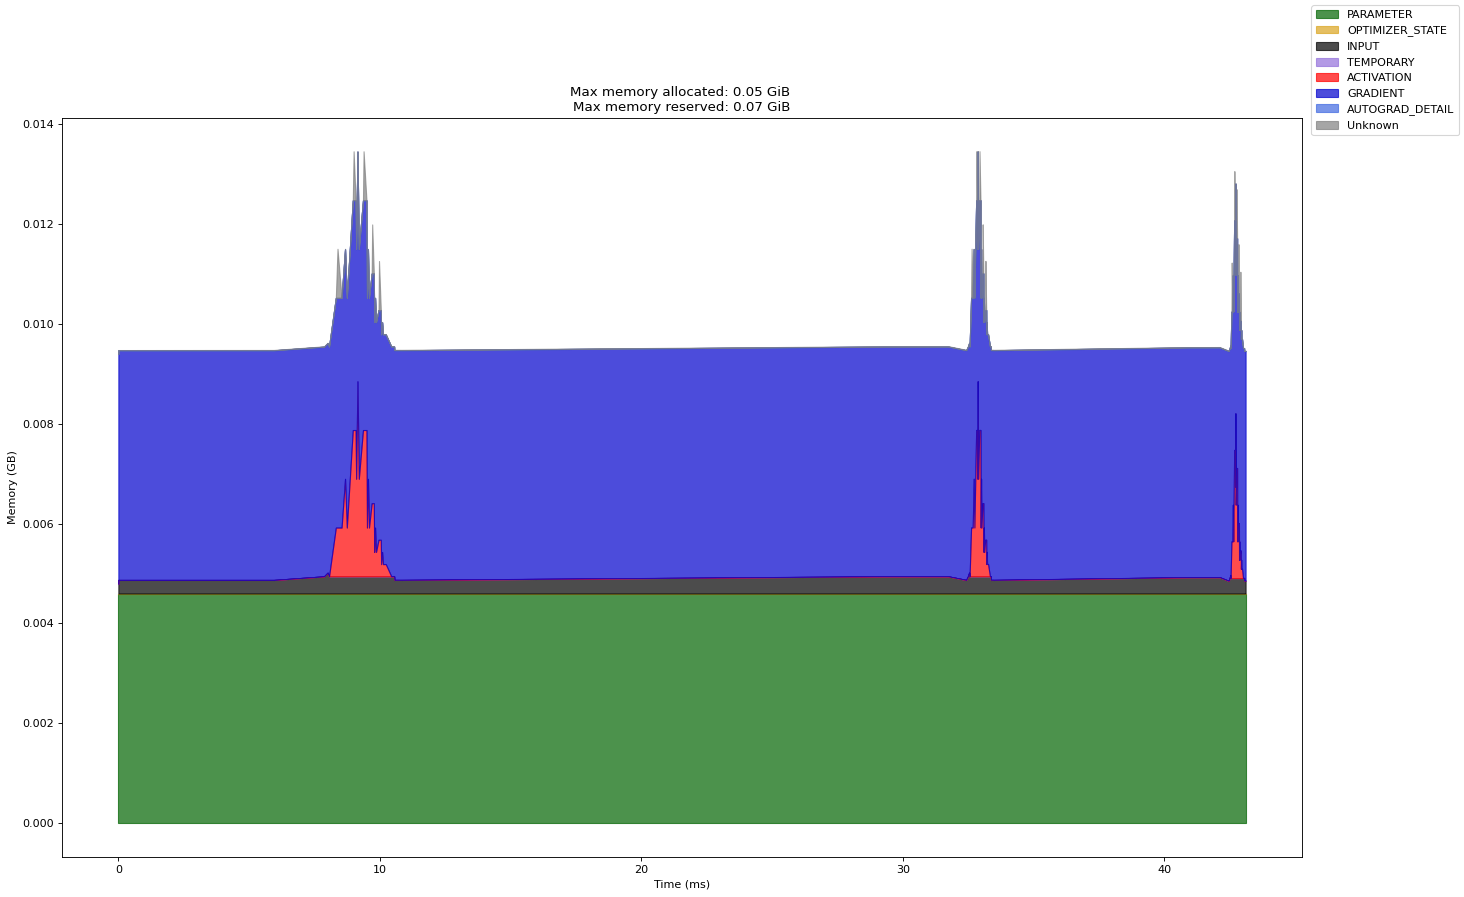

In [15]:
def profile_model_performance(model, dataloader, num_batches=5, log_dir="logs"):
    """Profile model with PyTorch Profiler"""
    model.eval()
    batch_size = dataloader.batch_size
    
    log_dir = Path(log_dir)
    tensorboard_logdir = (
        log_dir
        / f"tensorboard_bs{dataloader.batch_size}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    )
    os.makedirs(tensorboard_logdir, exist_ok=True)
    
    # TODO: Configure profiler settings as a reusable configuration dictionary
    # Hint: Create profiler_config dict with activities, record_shapes, profile_memory, etc.
    # Documentation: https://pytorch.org/docs/stable/profiler.html#torch.profiler.profile
    # KSW Code
    profiler_config = {
        "activities": [
            torch.profiler.ProfilerActivity.CPU,
            torch.profiler.ProfilerActivity.CUDA,
        ],
        "record_shapes": True,
        "profile_memory": True,
        "with_stack": True,
        "with_flops": True,
        "on_trace_ready":tensorboard_trace_handler(tensorboard_logdir),
    }

    
    with torch.profiler.profile(**profiler_config) as prof:    
        with torch.no_grad():
            for i, (inputs, _) in enumerate(dataloader):
                if i >= num_batches:
                    break
                
                # TODO: Run model inference with profiling
                # Hint: How does the profiler know that the next iteration has started?
                # Documentation: https://pytorch.org/docs/stable/profiler.html#torch.profiler.profile
                # KSW Code
                inputs = inputs.to(device)
                output = model(inputs)
                prof.step()
                
    print("Tensorboard trace saved to:", tensorboard_logdir)   
    
    memory_html = tensorboard_logdir / "memory_timeline.html"
    memory_json = tensorboard_logdir / "memory_timeline.json"
    
    prof.export_memory_timeline(str(memory_html))
    prof.export_memory_timeline(str(memory_json))
    
    print(f"Memory timeline saved to: {memory_html}")
    print(f"Memory timeline saved to: {memory_json}")
                              
    return prof

# Profile the model with batch size 64
print("Starting detailed profiling...")
profiler_result = profile_model_performance(model, test_dataloaders[512])

print("Profiling complete!")

In [16]:
# Analyze profiling results

print("=== TOP 10 MOST TIME-CONSUMING OPERATIONS ===")
# TODO: Display operations that take the most total time on the GPU
# Hint: Consider grouping operations based on how they're called, and look for a method to summarize and rank them by total GPU time.
# The profiler has an API for generating a table of summarized events: https://pytorch.org/docs/stable/profiler.html
# KSW Code
top_ops = profiler_result.key_averages(group_by_input_shape=True).table(
    sort_by="device_time_total",
    row_limit=10
)
print(top_ops)

print("\n=== MEMORY-INTENSIVE OPERATIONS ===")
# TODO: Highlight operations responsible for the most GPU memory usage
# Hint: Focus on identifying which operations allocate the most memory directly (not cumulative usage).
# There's a metric related to "self" memory usage that can help isolate expensive memory allocators: https://pytorch.org/docs/stable/profiler.html
# KSW Code
memory_ops = profiler_result.key_averages(group_by_input_shape=True).table(
    sort_by="self_device_memory_usage",
    row_limit=10
)
print(memory_ops)

print("\n=== CPU vs CUDA TIME ANALYSIS ===")
# TODO: Identify operations with large discrepancies between CPU and GPU execution time
# Hint: Look for signs of CPU-GPU synchronization delays; these usually appear when CPU time dominates.
# Try sorting by total CPU time and observe the ratio of CPU to CUDA time for each operation: https://pytorch.org/tutorials/recipes/recipes/profiler_recipe.html
# KSW Code
cpu_analysis = profiler_result.key_averages(group_by_input_shape=True).table(
    sort_by="cpu_time_total",
    row_limit=10
)
print(cpu_analysis)

print("\n=== OPERATION CALL FREQUENCY ANALYSIS ===")
# TODO: Detect frequently called operations with minimal per-call overhead
# Hint: Sorting by how often operations are called can uncover inefficiencies in batching or kernel launches.
# High frequency + low time per call = potential optimization opportunity: https://pytorch.org/docs/stable/profiler.html
# KSW Code
frequency_analysis = profiler_result.key_averages(group_by_input_shape=True).table(
    sort_by="count",
    row_limit=10
)

print(frequency_analysis)


=== TOP 10 MOST TIME-CONSUMING OPERATIONS ===
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ---------------------------------------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls                                   Input Shapes  Total KFLOPs  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ---------------------------------------------  ------------  
enumera

#### 📌 Function: prof.key_averages() in pandas data frame
- prof.key_averages().table is pretty unreadable
- dataformatting using pandas makes it more readable

In [17]:
def profiler_to_df(prof):
    events = prof.key_averages()

    total_self_cpu_us = sum(evt.self_cpu_time_total for evt in events)
    total_self_gpu_us = sum(
        getattr(evt, "self_device_time_total",
                getattr(evt, "self_cuda_time_total", 0))
        for evt in events
    )

    rows = []

    for evt in events:
        # ---------------- CPU TIME ----------------
        self_cpu_us = evt.self_cpu_time_total
        cpu_total_us = evt.cpu_time_total

        # ---------------- GPU TIME ----------------
        self_gpu_us = getattr(
            evt, "self_device_time_total",
            getattr(evt, "self_cuda_time_total", 0)
        )

        gpu_total_us = getattr(
            evt, "device_time_total",
            getattr(evt, "cuda_time_total", 0)
        )

        # ---------------- MEMORY (FIXED PATCH) ----------------
        cpu_mem = getattr(evt, "cpu_memory_usage", 0)
        cpu_self_mem = getattr(evt, "self_cpu_memory_usage", 0)

        gpu_mem = getattr(
            evt, "device_memory_usage",
            getattr(evt, "cuda_memory_usage", 0)
        )

        gpu_self_mem = getattr(
            evt, "self_device_memory_usage",
            getattr(evt, "self_cuda_memory_usage", 0)
        )

        rows.append({
            "Name": evt.key,

            # ---------------- CPU ----------------
            "CPU Time Self %": (self_cpu_us / total_self_cpu_us * 100) if total_self_cpu_us else 0,
            "CPU Time Self (ms)": self_cpu_us / 1000,

            "CPU Time Total %": (cpu_total_us / total_self_cpu_us * 100) if total_self_cpu_us else 0,
            "CPU Time Total (ms)": cpu_total_us / 1000,
            "CPU Time Avg (ms)": (cpu_total_us / evt.count / 1000) if evt.count else 0,

            # ---------------- GPU ----------------
            "CUDA Time Self %": (self_gpu_us / total_self_gpu_us * 100) if total_self_gpu_us else 0,
            "CUDA Time Self (ms)": self_gpu_us / 1000,

            "CUDA Time Total %": (gpu_total_us / total_self_gpu_us * 100) if total_self_gpu_us else 0,
            "CUDA Time Total (ms)": gpu_total_us / 1000,
            "CUDA Time Avg (ms)": (gpu_total_us / evt.count / 1000) if evt.count else 0,

            # ---------------- CALLS ----------------
            "Num Calls": evt.count,

            # ---------------- MEMORY ---------------            
            "CPU Mem Self (MB)": cpu_self_mem / (1024**2) if cpu_self_mem else 0,
            "CPU Mem Total (MB)": cpu_mem / (1024**2) if cpu_mem else 0,

            "CUDA Mem Total (MB)": gpu_mem / (1024**2) if gpu_mem else 0,
            "CUDA Mem Self (MB)": gpu_self_mem / (1024**2) if gpu_self_mem else 0,
        })

    return pd.DataFrame(rows)


# ---------------- STYLE FORMATTER ----------------
def pretty_display(df):
    return df.style.format({
        "CPU Time Self %": "{:.2f}",
        "CPU Time Self (ms)": "{:.3f}",
        "CPU Time Total %": "{:.2f}",
        "CPU Time Total (ms)": "{:.3f}",
        "CPU Time Avg (ms)": "{:.3f}",

        "CUDA Time Self %": "{:.2f}",
        "CUDA Time Self (ms)": "{:.3f}",
        "CUDA Time Total %": "{:.2f}",
        "CUDA Time Total (ms)": "{:.3f}",
        "CUDA Time Avg (ms)": "{:.3f}",

        "CPU Mem Self (MB)": "{:.2f}",
        "CPU Mem Total (MB)": "{:.2f}",        
        "CUDA Mem Self (MB)": "{:.2f}",
        "CUDA Mem Total (MB)": "{:.2f}",
    })

def display_pandas(prof, mode, top_k):
    df = profiler_to_df(prof)
    print("------- ", mode, " TOP OPERATIONS: by call --------")
    display(pretty_display(df.sort_values("Num Calls", ascending=False).head(top_k)))
    
    print("------- ", mode, " TOP OPERATIONS: CPU TIME  --------")
    display(pretty_display(df.sort_values("CPU Time Self (ms)", ascending=False).head(top_k)))
    
    print("------- ", mode, " TOP OPERATIONS: CPU MEMORY  --------")
    display(pretty_display(df.sort_values("CPU Mem Self (MB)", ascending=False).head(top_k)))
    
    if torch.cuda.is_available():
        print("------- ", mode, " TOP OPERATIONS: CUDA TIME  --------")
        display(pretty_display(df.sort_values("CUDA Time Self (ms)", ascending=False).head(top_k)))
    
        print("------- ", mode, " TOP OPERATIONS: CUDA MEMORY  --------")
        display(pretty_display(df.sort_values("CUDA Mem Self (MB)", ascending=False).head(top_k)))

    return df
    

In [18]:
def display_pandas_match_tensorboard(df, mode, top_k):
    #------------------------------------------------------------------------------------------
    ## CPU: Making profile.key_averages().table comparable to TensorBoard Operator View
    #------------------------------------------------------------------------------------------
    print("------- ", mode, " TOP OPERATIONS: CPU TIME (MATCHED WITH TENSORBOARD) --------")
    df_cpu_ops_only = df[
        ~df["Name"].str.startswith("cuda", na=False)
        & ~df["Name"].str.contains("ProfilerStep", na=False)
        & ~df["Name"].str.contains("enumerate", na=False)
    ]
    
    df_cpu_ops_only = df_cpu_ops_only.sort_values("CPU Time Total (ms)", ascending=False)
    
    display(pretty_display(df_cpu_ops_only.head(top_k)))
    
    
    #------------------------------------------------------------------------------------------
    ## GPU: Making profile.key_averages().table comparable to TensorBoard GPU Kernel View
    #------------------------------------------------------------------------------------------
    # rows that are actual GPU kernels:
    # - have CUDA self time
    # - are NOT aten ops
    # - are NOT cuda runtime API calls
    # - are NOT ProfilerStep
    print("------- ", mode, " TOP OPERATIONS: CUDA TIME (MATCHED WITH TENSORBOARD) --------")
    kernel_df = df[
        (df["CUDA Time Total (ms)"] > 0)
        & ~df["Name"].str.startswith("aten::", na=False)
        & ~df["Name"].str.startswith("cuda", na=False)
        & ~df["Name"].str.contains("ProfilerStep", na=False)
    ]
    
    kernel_df = kernel_df.sort_values("CUDA Time Total (ms)", ascending=False)
    
    display(pretty_display(kernel_df.head(top_k)))

In [19]:
df_infer = display_pandas(profiler_result, "INFERENCE-BATCHSIZE_512", 10)

-------  INFERENCE-BATCHSIZE_512  TOP OPERATIONS: by call --------


,Name,CPU Time Self %,CPU Time Self (ms),CPU Time Total %,CPU Time Total (ms),CPU Time Avg (ms),CUDA Time Self %,CUDA Time Self (ms),CUDA Time Total %,CUDA Time Total (ms),CUDA Time Avg (ms),Num Calls,CPU Mem Self (MB),CPU Mem Total (MB),CUDA Mem Total (MB),CUDA Mem Self (MB)
7,aten::as_strided,4.26,3.689,4.26,3.689,0.001,0.00,0.000,0.00,0.000,0.000,4251,0.00,0.00,0.00,0.00
6,aten::select,23.63,20.486,26.76,23.200,0.008,0.00,0.000,0.00,0.000,0.000,2818,0.00,0.00,0.00,0.00
14,aten::unsqueeze,4.80,4.160,5.88,5.095,0.004,0.00,0.000,0.00,0.000,0.000,1409,0.00,0.00,0.00,0.00
10,cudaLaunchKernel,0.93,0.807,0.93,0.807,0.011,0.00,0.000,0.00,0.000,0.000,72,0.00,0.00,0.00,0.00
4,[memory],0.00,0.000,0.00,0.000,0.000,0.00,0.000,0.00,0.000,0.000,61,-0.00,-0.00,-27.09,-27.09
12,"void at::native::(anonymous namespace)::CatArrayBatchedCopy_contig, unsigned int, 1, 128, 1>(at::native::(anonymous namespace)::OpaqueType<4u>*, at::native::(anonymous namespace)::CatArrInputTensorMetadata, unsigned int, 128, 1>, at::native::(anonymous namespace)::TensorSizeStride, int, unsigned int)",0.00,0.000,0.00,0.000,0.000,0.40,0.049,0.40,0.049,0.002,24,0.00,0.00,0.00,0.00
23,aten::addmm,1.12,0.974,1.66,1.442,0.080,9.93,1.230,9.93,1.230,0.068,18,0.00,0.00,13.45,-1.55
22,aten::transpose,0.09,0.078,0.13,0.111,0.006,0.00,0.000,0.00,0.000,0.000,18,0.00,0.00,0.00,0.00
21,aten::t,0.12,0.103,0.25,0.214,0.012,0.00,0.000,0.00,0.000,0.000,18,0.00,0.00,0.00,0.00
20,aten::linear,0.20,0.174,2.11,1.829,0.102,0.00,0.000,9.93,1.230,0.068,18,0.00,0.00,13.45,0.00


-------  INFERENCE-BATCHSIZE_512  TOP OPERATIONS: CPU TIME  --------


,Name,CPU Time Self %,CPU Time Self (ms),CPU Time Total %,CPU Time Total (ms),CPU Time Avg (ms),CUDA Time Self %,CUDA Time Self (ms),CUDA Time Total %,CUDA Time Total (ms),CUDA Time Avg (ms),Num Calls,CPU Mem Self (MB),CPU Mem Total (MB),CUDA Mem Total (MB),CUDA Mem Self (MB)
5,enumerate(DataLoader)#_SingleProcessDataLoaderIter.__next__,57.20,49.595,96.39,83.568,20.892,0.00,0.000,0.40,0.049,0.012,4,0.00,0.00,0.21,0.00
6,aten::select,23.63,20.486,26.76,23.200,0.008,0.00,0.000,0.00,0.000,0.000,2818,0.00,0.00,0.00,0.00
14,aten::unsqueeze,4.80,4.160,5.88,5.095,0.004,0.00,0.000,0.00,0.000,0.000,1409,0.00,0.00,0.00,0.00
8,aten::stack,4.47,3.875,12.42,10.772,1.795,0.00,0.000,0.40,0.049,0.008,6,0.00,0.00,0.21,0.00
7,aten::as_strided,4.26,3.689,4.26,3.689,0.001,0.00,0.000,0.00,0.000,0.000,4251,0.00,0.00,0.00,0.00
9,aten::cat,1.67,1.446,2.06,1.787,0.298,0.40,0.049,0.40,0.049,0.008,6,0.00,0.00,0.21,0.21
23,aten::addmm,1.12,0.974,1.66,1.442,0.080,9.93,1.230,9.93,1.230,0.068,18,0.00,0.00,13.45,-1.55
10,cudaLaunchKernel,0.93,0.807,0.93,0.807,0.011,0.00,0.000,0.00,0.000,0.000,72,0.00,0.00,0.00,0.00
27,aten::clamp_min,0.26,0.227,0.41,0.356,0.024,1.00,0.124,1.00,0.124,0.008,15,0.00,0.00,13.07,13.07
20,aten::linear,0.20,0.174,2.11,1.829,0.102,0.00,0.000,9.93,1.230,0.068,18,0.00,0.00,13.45,0.00


-------  INFERENCE-BATCHSIZE_512  TOP OPERATIONS: CPU MEMORY  --------


,Name,CPU Time Self %,CPU Time Self (ms),CPU Time Total %,CPU Time Total (ms),CPU Time Avg (ms),CUDA Time Self %,CUDA Time Self (ms),CUDA Time Total %,CUDA Time Total (ms),CUDA Time Avg (ms),Num Calls,CPU Mem Self (MB),CPU Mem Total (MB),CUDA Mem Total (MB),CUDA Mem Self (MB)
0,aten::empty,0.20,0.173,0.20,0.173,0.011,0.00,0.000,0.00,0.000,0.000,16,0.00,0.00,15.00,15.00
35,aten::expand,0.02,0.017,0.02,0.021,0.007,0.00,0.000,0.00,0.000,0.000,3,0.00,0.00,0.00,0.00
26,aten::relu,0.11,0.098,0.52,0.453,0.030,0.00,0.000,1.00,0.124,0.008,15,0.00,0.00,13.07,0.00
27,aten::clamp_min,0.26,0.227,0.41,0.356,0.024,1.00,0.124,1.00,0.124,0.008,15,0.00,0.00,13.07,13.07
28,"void at::native::vectorized_elementwise_kernel<4, at::native::(anonymous namespace)::launch_clamp_scalar(at::TensorIteratorBase&, c10::Scalar, c10::Scalar, at::native::detail::ClampLimits)::{lambda()#1}::operator()() const::{lambda()#7}::operator()() const::{lambda(float)#1}, std::array >(int, at::native::(anonymous namespace)::launch_clamp_scalar(at::TensorIteratorBase&, c10::Scalar, c10::Scalar, at::native::detail::ClampLimits)::{lambda()#1}::operator()() const::{lambda()#7}::operator()() const::{lambda(float)#1}, std::array)",0.00,0.000,0.00,0.000,0.000,1.00,0.124,1.00,0.124,0.008,15,0.00,0.00,0.00,0.00
29,aten::dropout,0.02,0.016,0.02,0.016,0.001,0.00,0.000,0.00,0.000,0.000,15,0.00,0.00,0.00,0.00
30,ampere_sgemm_128x64_tn,0.00,0.000,0.00,0.000,0.000,3.57,0.443,3.57,0.443,0.148,3,0.00,0.00,0.00,0.00
31,cudaMemsetAsync,0.10,0.089,0.10,0.089,0.010,0.00,0.000,0.00,0.000,0.000,9,0.00,0.00,0.00,0.00
32,Memset (Device),0.00,0.000,0.00,0.000,0.000,0.03,0.004,0.03,0.004,0.000,9,0.00,0.00,0.00,0.00
33,ampere_sgemm_128x32_tn,0.00,0.000,0.00,0.000,0.000,4.88,0.604,4.88,0.604,0.121,5,0.00,0.00,0.00,0.00


-------  INFERENCE-BATCHSIZE_512  TOP OPERATIONS: CUDA TIME  --------


,Name,CPU Time Self %,CPU Time Self (ms),CPU Time Total %,CPU Time Total (ms),CPU Time Avg (ms),CUDA Time Self %,CUDA Time Self (ms),CUDA Time Total %,CUDA Time Total (ms),CUDA Time Avg (ms),Num Calls,CPU Mem Self (MB),CPU Mem Total (MB),CUDA Mem Total (MB),CUDA Mem Self (MB)
11,enumerate(DataLoader)#_SingleProcessDataLoaderIter.__next__,0.00,0.000,0.00,0.000,0.000,76.88,9.519,76.88,9.519,3.173,3,0.00,0.00,0.00,0.00
23,aten::addmm,1.12,0.974,1.66,1.442,0.080,9.93,1.230,9.93,1.230,0.068,18,0.00,0.00,13.45,-1.55
33,ampere_sgemm_128x32_tn,0.00,0.000,0.00,0.000,0.000,4.88,0.604,4.88,0.604,0.121,5,0.00,0.00,0.00,0.00
30,ampere_sgemm_128x64_tn,0.00,0.000,0.00,0.000,0.000,3.57,0.443,3.57,0.443,0.148,3,0.00,0.00,0.00,0.00
27,aten::clamp_min,0.26,0.227,0.41,0.356,0.024,1.00,0.124,1.00,0.124,0.008,15,0.00,0.00,13.07,13.07
28,"void at::native::vectorized_elementwise_kernel<4, at::native::(anonymous namespace)::launch_clamp_scalar(at::TensorIteratorBase&, c10::Scalar, c10::Scalar, at::native::detail::ClampLimits)::{lambda()#1}::operator()() const::{lambda()#7}::operator()() const::{lambda(float)#1}, std::array >(int, at::native::(anonymous namespace)::launch_clamp_scalar(at::TensorIteratorBase&, c10::Scalar, c10::Scalar, at::native::detail::ClampLimits)::{lambda()#1}::operator()() const::{lambda()#7}::operator()() const::{lambda(float)#1}, std::array)",0.00,0.000,0.00,0.000,0.000,1.00,0.124,1.00,0.124,0.008,15,0.00,0.00,0.00,0.00
34,ampere_sgemm_32x32_sliced1x4_tn,0.00,0.000,0.00,0.000,0.000,0.60,0.074,0.60,0.074,0.025,3,0.00,0.00,0.00,0.00
9,aten::cat,1.67,1.446,2.06,1.787,0.298,0.40,0.049,0.40,0.049,0.008,6,0.00,0.00,0.21,0.21
12,"void at::native::(anonymous namespace)::CatArrayBatchedCopy_contig, unsigned int, 1, 128, 1>(at::native::(anonymous namespace)::OpaqueType<4u>*, at::native::(anonymous namespace)::CatArrInputTensorMetadata, unsigned int, 128, 1>, at::native::(anonymous namespace)::TensorSizeStride, int, unsigned int)",0.00,0.000,0.00,0.000,0.000,0.40,0.049,0.40,0.049,0.002,24,0.00,0.00,0.00,0.00
25,ampere_sgemm_32x128_tn,0.00,0.000,0.00,0.000,0.000,0.37,0.046,0.37,0.046,0.015,3,0.00,0.00,0.00,0.00


-------  INFERENCE-BATCHSIZE_512  TOP OPERATIONS: CUDA MEMORY  --------


,Name,CPU Time Self %,CPU Time Self (ms),CPU Time Total %,CPU Time Total (ms),CPU Time Avg (ms),CUDA Time Self %,CUDA Time Self (ms),CUDA Time Total %,CUDA Time Total (ms),CUDA Time Avg (ms),Num Calls,CPU Mem Self (MB),CPU Mem Total (MB),CUDA Mem Total (MB),CUDA Mem Self (MB)
0,aten::empty,0.20,0.173,0.20,0.173,0.011,0.00,0.000,0.00,0.000,0.000,16,0.00,0.00,15.00,15.00
27,aten::clamp_min,0.26,0.227,0.41,0.356,0.024,1.00,0.124,1.00,0.124,0.008,15,0.00,0.00,13.07,13.07
9,aten::cat,1.67,1.446,2.06,1.787,0.298,0.40,0.049,0.40,0.049,0.008,6,0.00,0.00,0.21,0.21
18,aten::mul,0.08,0.071,0.11,0.098,0.033,0.04,0.005,0.04,0.005,0.002,3,0.00,0.00,0.20,0.20
16,aten::add,0.15,0.134,0.22,0.191,0.064,0.04,0.005,0.04,0.005,0.002,3,0.00,0.00,0.20,0.20
38,aten::sigmoid,0.07,0.059,0.10,0.085,0.028,0.04,0.005,0.04,0.005,0.002,3,0.00,0.00,0.01,0.01
40,aten::mean,0.14,0.123,0.18,0.155,0.052,0.08,0.010,0.08,0.010,0.003,3,0.00,0.00,0.00,0.00
34,ampere_sgemm_32x32_sliced1x4_tn,0.00,0.000,0.00,0.000,0.000,0.60,0.074,0.60,0.074,0.025,3,0.00,0.00,0.00,0.00
28,"void at::native::vectorized_elementwise_kernel<4, at::native::(anonymous namespace)::launch_clamp_scalar(at::TensorIteratorBase&, c10::Scalar, c10::Scalar, at::native::detail::ClampLimits)::{lambda()#1}::operator()() const::{lambda()#7}::operator()() const::{lambda(float)#1}, std::array >(int, at::native::(anonymous namespace)::launch_clamp_scalar(at::TensorIteratorBase&, c10::Scalar, c10::Scalar, at::native::detail::ClampLimits)::{lambda()#1}::operator()() const::{lambda()#7}::operator()() const::{lambda(float)#1}, std::array)",0.00,0.000,0.00,0.000,0.000,1.00,0.124,1.00,0.124,0.008,15,0.00,0.00,0.00,0.00
29,aten::dropout,0.02,0.016,0.02,0.016,0.001,0.00,0.000,0.00,0.000,0.000,15,0.00,0.00,0.00,0.00


In [20]:
display_pandas_match_tensorboard(df_infer, "INFERENCE-BATCHSIZE_512", 10)

-------  INFERENCE-BATCHSIZE_512  TOP OPERATIONS: CPU TIME (MATCHED WITH TENSORBOARD) --------


,Name,CPU Time Self %,CPU Time Self (ms),CPU Time Total %,CPU Time Total (ms),CPU Time Avg (ms),CUDA Time Self %,CUDA Time Self (ms),CUDA Time Total %,CUDA Time Total (ms),CUDA Time Avg (ms),Num Calls,CPU Mem Self (MB),CPU Mem Total (MB),CUDA Mem Total (MB),CUDA Mem Self (MB)
6,aten::select,23.63,20.486,26.76,23.200,0.008,0.00,0.000,0.00,0.000,0.000,2818,0.00,0.00,0.00,0.00
8,aten::stack,4.47,3.875,12.42,10.772,1.795,0.00,0.000,0.40,0.049,0.008,6,0.00,0.00,0.21,0.00
14,aten::unsqueeze,4.80,4.160,5.88,5.095,0.004,0.00,0.000,0.00,0.000,0.000,1409,0.00,0.00,0.00,0.00
7,aten::as_strided,4.26,3.689,4.26,3.689,0.001,0.00,0.000,0.00,0.000,0.000,4251,0.00,0.00,0.00,0.00
20,aten::linear,0.20,0.174,2.11,1.829,0.102,0.00,0.000,9.93,1.230,0.068,18,0.00,0.00,13.45,0.00
9,aten::cat,1.67,1.446,2.06,1.787,0.298,0.40,0.049,0.40,0.049,0.008,6,0.00,0.00,0.21,0.21
23,aten::addmm,1.12,0.974,1.66,1.442,0.080,9.93,1.230,9.93,1.230,0.068,18,0.00,0.00,13.45,-1.55
26,aten::relu,0.11,0.098,0.52,0.453,0.030,0.00,0.000,1.00,0.124,0.008,15,0.00,0.00,13.07,0.00
27,aten::clamp_min,0.26,0.227,0.41,0.356,0.024,1.00,0.124,1.00,0.124,0.008,15,0.00,0.00,13.07,13.07
21,aten::t,0.12,0.103,0.25,0.214,0.012,0.00,0.000,0.00,0.000,0.000,18,0.00,0.00,0.00,0.00


-------  INFERENCE-BATCHSIZE_512  TOP OPERATIONS: CUDA TIME (MATCHED WITH TENSORBOARD) --------


,Name,CPU Time Self %,CPU Time Self (ms),CPU Time Total %,CPU Time Total (ms),CPU Time Avg (ms),CUDA Time Self %,CUDA Time Self (ms),CUDA Time Total %,CUDA Time Total (ms),CUDA Time Avg (ms),Num Calls,CPU Mem Self (MB),CPU Mem Total (MB),CUDA Mem Total (MB),CUDA Mem Self (MB)
11,enumerate(DataLoader)#_SingleProcessDataLoaderIter.__next__,0.00,0.000,0.00,0.000,0.000,76.88,9.519,76.88,9.519,3.173,3,0.00,0.00,0.00,0.00
33,ampere_sgemm_128x32_tn,0.00,0.000,0.00,0.000,0.000,4.88,0.604,4.88,0.604,0.121,5,0.00,0.00,0.00,0.00
30,ampere_sgemm_128x64_tn,0.00,0.000,0.00,0.000,0.000,3.57,0.443,3.57,0.443,0.148,3,0.00,0.00,0.00,0.00
28,"void at::native::vectorized_elementwise_kernel<4, at::native::(anonymous namespace)::launch_clamp_scalar(at::TensorIteratorBase&, c10::Scalar, c10::Scalar, at::native::detail::ClampLimits)::{lambda()#1}::operator()() const::{lambda()#7}::operator()() const::{lambda(float)#1}, std::array >(int, at::native::(anonymous namespace)::launch_clamp_scalar(at::TensorIteratorBase&, c10::Scalar, c10::Scalar, at::native::detail::ClampLimits)::{lambda()#1}::operator()() const::{lambda()#7}::operator()() const::{lambda(float)#1}, std::array)",0.00,0.000,0.00,0.000,0.000,1.00,0.124,1.00,0.124,0.008,15,0.00,0.00,0.00,0.00
34,ampere_sgemm_32x32_sliced1x4_tn,0.00,0.000,0.00,0.000,0.000,0.60,0.074,0.60,0.074,0.025,3,0.00,0.00,0.00,0.00
5,enumerate(DataLoader)#_SingleProcessDataLoaderIter.__next__,57.20,49.595,96.39,83.568,20.892,0.00,0.000,0.40,0.049,0.012,4,0.00,0.00,0.21,0.00
12,"void at::native::(anonymous namespace)::CatArrayBatchedCopy_contig, unsigned int, 1, 128, 1>(at::native::(anonymous namespace)::OpaqueType<4u>*, at::native::(anonymous namespace)::CatArrInputTensorMetadata, unsigned int, 128, 1>, at::native::(anonymous namespace)::TensorSizeStride, int, unsigned int)",0.00,0.000,0.00,0.000,0.000,0.40,0.049,0.40,0.049,0.002,24,0.00,0.00,0.00,0.00
25,ampere_sgemm_32x128_tn,0.00,0.000,0.00,0.000,0.000,0.37,0.046,0.37,0.046,0.015,3,0.00,0.00,0.00,0.00
45,ampere_sgemm_64x32_sliced1x4_tn,0.00,0.000,0.00,0.000,0.000,0.36,0.045,0.36,0.045,0.045,1,0.00,0.00,0.00,0.00
41,"void at::native::reduce_kernel<512, 1, at::native::ReduceOp, unsigned int, float, 4> >(at::native::ReduceOp, unsigned int, float, 4>)",0.00,0.000,0.00,0.000,0.000,0.08,0.010,0.08,0.010,0.003,3,0.00,0.00,0.00,0.00


> TODO: Extract key performance insights from PyTorch profiler output
> 
> Hint: Focus on identifying CPU-GPU synchronization issues (high CPU time + low CUDA time) and kernel launch overhead (many small operations).
> 
> Find inspiration at https://pytorch.org/tutorials/recipes/recipes/profiler_recipe.html#analyzing-performance

### Step 7: Profile layer-by-layer model performance

While Step 6 revealed data loading as our primary bottleneck, we should also understand how our individual model layers perform on GPU. Even though the model represents only ~3% of execution time, layer-level analysis helps identify which architectural components are GPU-efficient versus CPU-bound, providing our optimization priorities once we fix the data pipeline.

In [21]:
# Analyze performance by model layer
def analyze_model_layers(profiler_result):
    """Break down performance by individual model layers"""
    
    # TODO: Extract only layer-specific operations from profiler results
    # Hint: Filter profiler_result's events 'for events containing layer names like 'linear', 'relu', ...
    # KSW Code
    layer_keywords = [
        "linear", "addmm", "relu", "dropout", "sigmoid",
        "add", "mul", "mean"
    ]

    layer_events = [
        event for event in profiler_result.key_averages()
        if any(keyword in event.key.lower() for keyword in layer_keywords)
    ]
    
    print("=== LAYER-BY-LAYER PERFORMANCE BREAKDOWN ===")
    layer_analysis = profiler_result.key_averages().table(
        sort_by="device_time_total", row_limit=15,
        header="Layer Performance Analysis"
    )
    print(layer_analysis)
    

    # TODO: Group layer events by operation type and calculate aggregate statistics
    # Hint: Create a dictionary where keys are layer types ('Linear Layers', 'ReLU Activations', etc.) 
    # and values contain summed `cuda_time``, `cpu_time``, `memory`` usage, and call `counts``
    # KSW Code
    layer_groups = {
        "Linear Layers": {
            "keywords": ["linear", "addmm"],
            "cuda_time": 0,
            "cpu_time": 0,
            "memory": 0,
            "count": 0,
        },
        "ReLU Activations": {
            "keywords": ["relu"],
            "cuda_time": 0,
            "cpu_time": 0,
            "memory": 0,
            "count": 0,
        },
        "Dropout Layers": {
            "keywords": ["dropout"],
            "cuda_time": 0,
            "cpu_time": 0,
            "memory": 0,
            "count": 0,
        },
        "Sigmoid Output": {
            "keywords": ["sigmoid"],
            "cuda_time": 0,
            "cpu_time": 0,
            "memory": 0,
            "count": 0,
        },
        "Unnecessary Add/Mul": {
            "keywords": ["add", "mul"],
            "cuda_time": 0,
            "cpu_time": 0,
            "memory": 0,
            "count": 0,
        },
        "Mean / Sync Path": {
            "keywords": ["mean", "item"],
            "cuda_time": 0,
            "cpu_time": 0,
            "memory": 0,
            "count": 0,
        },
    }

    for event in layer_events:
        event_name = event.key.lower()

        for layer_type, stats in layer_groups.items():
            if any(keyword in event_name for keyword in stats["keywords"]):
                stats["cuda_time"] += event.device_time_total
                stats["cpu_time"] += event.cpu_time_total
                stats["memory"] += event.self_device_memory_usage
                stats["count"] += event.count

    for stats in layer_groups.values():
        stats.pop("keywords")

    return layer_groups

layer_breakdown = analyze_model_layers(profiler_result)

# Visualize layer contributions
print("\n=== MODEL LAYER EFFICIENCY ANALYSIS ===")
for layer_type, stats in layer_breakdown.items():
    cuda_ms = stats['cuda_time'] / 1000
    cpu_ms = stats['cpu_time'] / 1000
    memory_mb = stats['memory'] / (1024**2)
    efficiency_ratio = cuda_ms / max(cpu_ms, 0.001)
    
    print(f"{layer_type}:")
    print(f"  CUDA time: {cuda_ms:.2f}ms | CPU time: {cpu_ms:.2f}ms")
    print(f"  Memory usage: {memory_mb:.1f}MB | Calls: {stats['count']}")
    print(f"  Efficiency ratio (CUDA/CPU): {efficiency_ratio:.2f}")
    print()

=== LAYER-BY-LAYER PERFORMANCE BREAKDOWN ===
Layer Performance Analysis
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  Total KFLOPs  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
enumerate(DataLoader)#_SingleProcessDataLoaderIter._...         0.00%       0.000us         0.00%       0.000us       0.00

> TODO: Analyze layer-level performance insights and their impact on optimization strategy
> 
> Hint: Focus on GPU efficiency ratios for each layer type and the relationship between number of operations and kernel launch overhead. How does this change your understanding of the primary performance bottleneck identified in Step 5?

## Bonus Step 8: Visualize timeline analysis
Let's create visualizations to understand the temporal behavior of our model.

=== TIMELINE ANALYSIS RESULTS ===
Chrome trace saved to: assets/exercise2/model_trace.json
Total CUDA time: 13.84 ms
Total CPU time: 134.71 ms
CUDA/CPU ratio: 0.10
Number of profiled events: 116


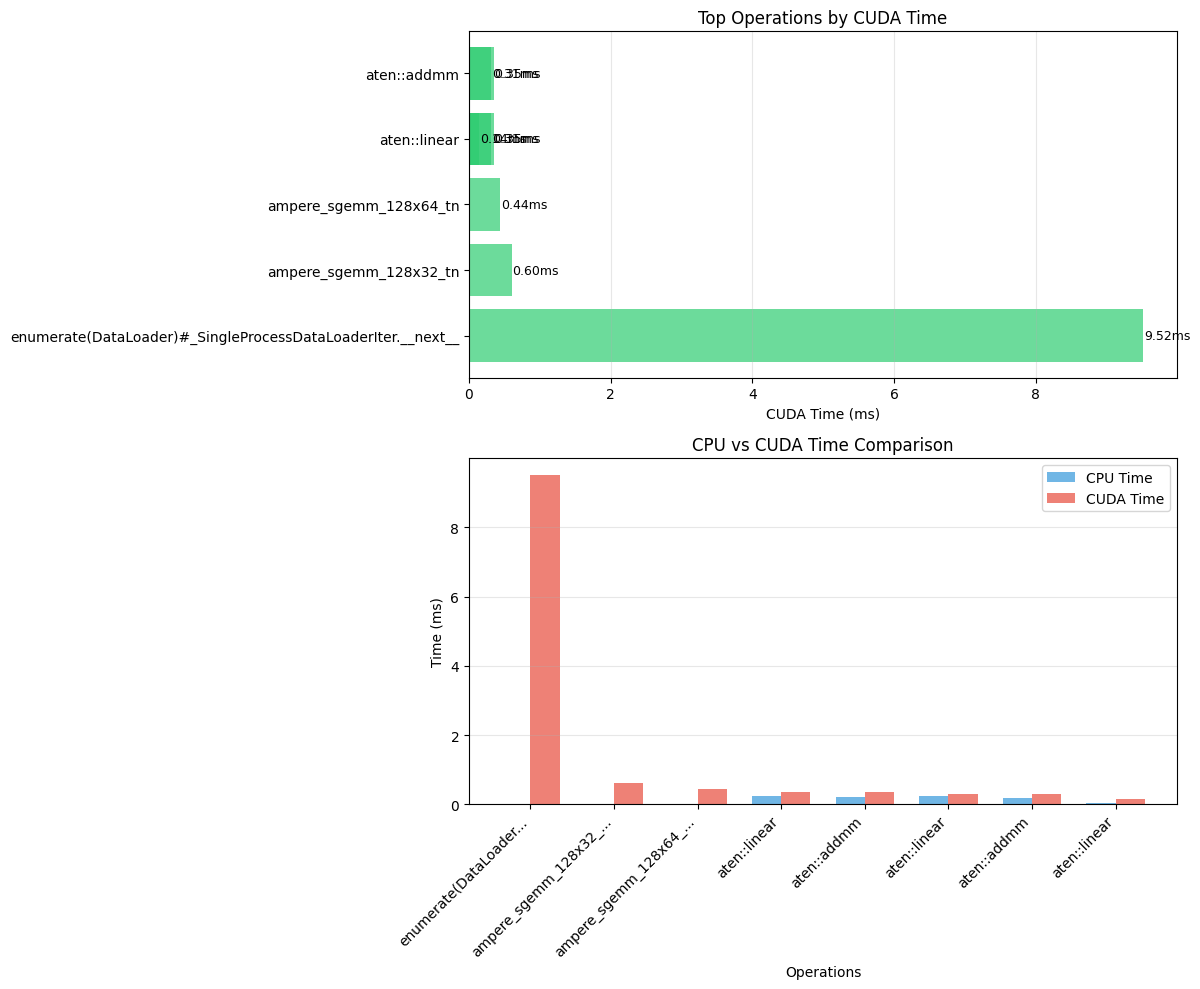

In [22]:
# Generate timeline trace for detailed temporal analysis
def generate_timeline_analysis(profiler_result, filename="model_trace"):
    """Generate timeline trace and basic analysis"""
    
    trace_file = os.path.join(output_dir, f"{filename}.json")
    # TODO: Export trace (can be viewed in chrome://tracing)
    # Hint: Look for exporting functions at https://docs.pytorch.org/docs/stable/profiler.html
    # And note that the export can be called only once for session
    
    # KSW Code    
    # TODO: Get detailed event information
    # Hint: # Tip: Start exploring with .key_averages(), then add grouping arguments.
    # Get summarized profiler events
    events = profiler_result.key_averages(group_by_input_shape=True)
    
    # TODO: Analyze GPU vs CPU time distribution
    # Hint: Each profiler event object contains both CPU and CUDA timing attributes.
    # Explore an event to find out all attributes
    # KSW Code
    total_cuda_time = sum(event.device_time_total for event in events)
    total_cpu_time = sum(event.cpu_time_total for event in events)
    
    timeline_stats = {
        'trace_file': trace_file,
        'total_cuda_time_ms': total_cuda_time / 1000,
        'total_cpu_time_ms': total_cpu_time / 1000,
        'cuda_cpu_ratio': total_cuda_time / max(total_cpu_time, 1),
        'num_events': len(events)
    }
    
    return timeline_stats, events

timeline_stats, detailed_events = generate_timeline_analysis(profiler_result)

print("=== TIMELINE ANALYSIS RESULTS ===")
print(f"Chrome trace saved to: {timeline_stats['trace_file']}")
print(f"Total CUDA time: {timeline_stats['total_cuda_time_ms']:.2f} ms")
print(f"Total CPU time: {timeline_stats['total_cpu_time_ms']:.2f} ms")
print(f"CUDA/CPU ratio: {timeline_stats['cuda_cpu_ratio']:.2f}")
print(f"Number of profiled events: {timeline_stats['num_events']}")

# Create visualization of the performance bottlenecks
def visualize_bottlenecks(events, top_n=8):
    """Create visualization of performance bottlenecks"""
    
    # TODO: Extract top_n operations by CUDA time, sort them, and extract relevant keys (names, cuda times in ms, and cpu times in ms)
    # Hint: The .cuda_time attribute (in microseconds) can help rank performance bottlenecks.
    # For the `names``, you may want to trim long operation names for better visualization.
    # KSW Code
    sorted_events = sorted(
        events,
        key=lambda e: e.device_time_total,
        reverse=True
    )[:top_n]

    names = [event.key for event in sorted_events]

    cuda_times = [
        event.device_time_total / 1000
        for event in sorted_events
    ]

    cpu_times = [
        event.cpu_time_total / 1000
        for event in sorted_events
    ]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # CUDA time breakdown
    bars1 = ax1.barh(names, cuda_times, color='#2ecc71', alpha=0.7)
    ax1.set_xlabel('CUDA Time (ms)')
    ax1.set_title('Top Operations by CUDA Time')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar, time_val in zip(bars1, cuda_times):
        ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{time_val:.2f}ms', va='center', fontsize=9)
    
    # CPU vs CUDA comparison
    x_pos = np.arange(len(names))
    width = 0.35
    
    bars2 = ax2.bar(x_pos - width/2, cpu_times, width, label='CPU Time', 
                    color='#3498db', alpha=0.7)
    bars3 = ax2.bar(x_pos + width/2, cuda_times, width, label='CUDA Time', 
                    color='#e74c3c', alpha=0.7)
    
    ax2.set_xlabel('Operations')
    ax2.set_ylabel('Time (ms)')
    ax2.set_title('CPU vs CUDA Time Comparison')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([name[:20] + "..." if len(name) > 20 else name 
                        for name in names], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'performance_bottlenecks.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return sorted_events

top_bottlenecks = visualize_bottlenecks(detailed_events)

> **Timeline visualization**: You can open the generated Chrome trace file in Chrome browser by navigating to chrome://tracing and loading the JSON file for detailed timeline analysis. This gives a detailed, interactive timeline of CPU and GPU activities, helping you pinpoint performance bottlenecks like synchronization delays, long-running ops, or kernel launch gaps.
>
> And, it's also a great artifact to share with your team when reviewing model performance!

### Bonus Step 9: Run Pytorch Profiling Across  all batch sizes
Use the dataloader tied to each batch size

batch_sizes =  [32, 64, 128, 512, 1024, 2048, 4096]

i) Running Pytorch profiler , ii) generating tensor board logs, ii) memory timeline for batch size =  32
Tensorboard trace saved to: logs/tensorboard_bs32_20260619_155243
Memory timeline saved to: logs/tensorboard_bs32_20260619_155243/memory_timeline.html
Memory timeline saved to: logs/tensorboard_bs32_20260619_155243/memory_timeline.json
COMPLETED: i) Running Pytorch profiler , ii) generating tensor board logs, ii) memory timeline for batch size =  32



i) Running Pytorch profiler , ii) generating tensor board logs, ii) memory timeline for batch size =  64
Tensorboard trace saved to: logs/tensorboard_bs64_20260619_155244
Memory timeline saved to: logs/tensorboard_bs64_20260619_155244/memory_timeline.html
Memory timeline saved to: logs/tensorboard_bs64_20260619_155244/memory_timeline.json
COMPLETED: i) Running Pytorch profiler , ii) generating tensor board logs, ii) memory timeline for batch size =  64



i) Running Pytorch profiler

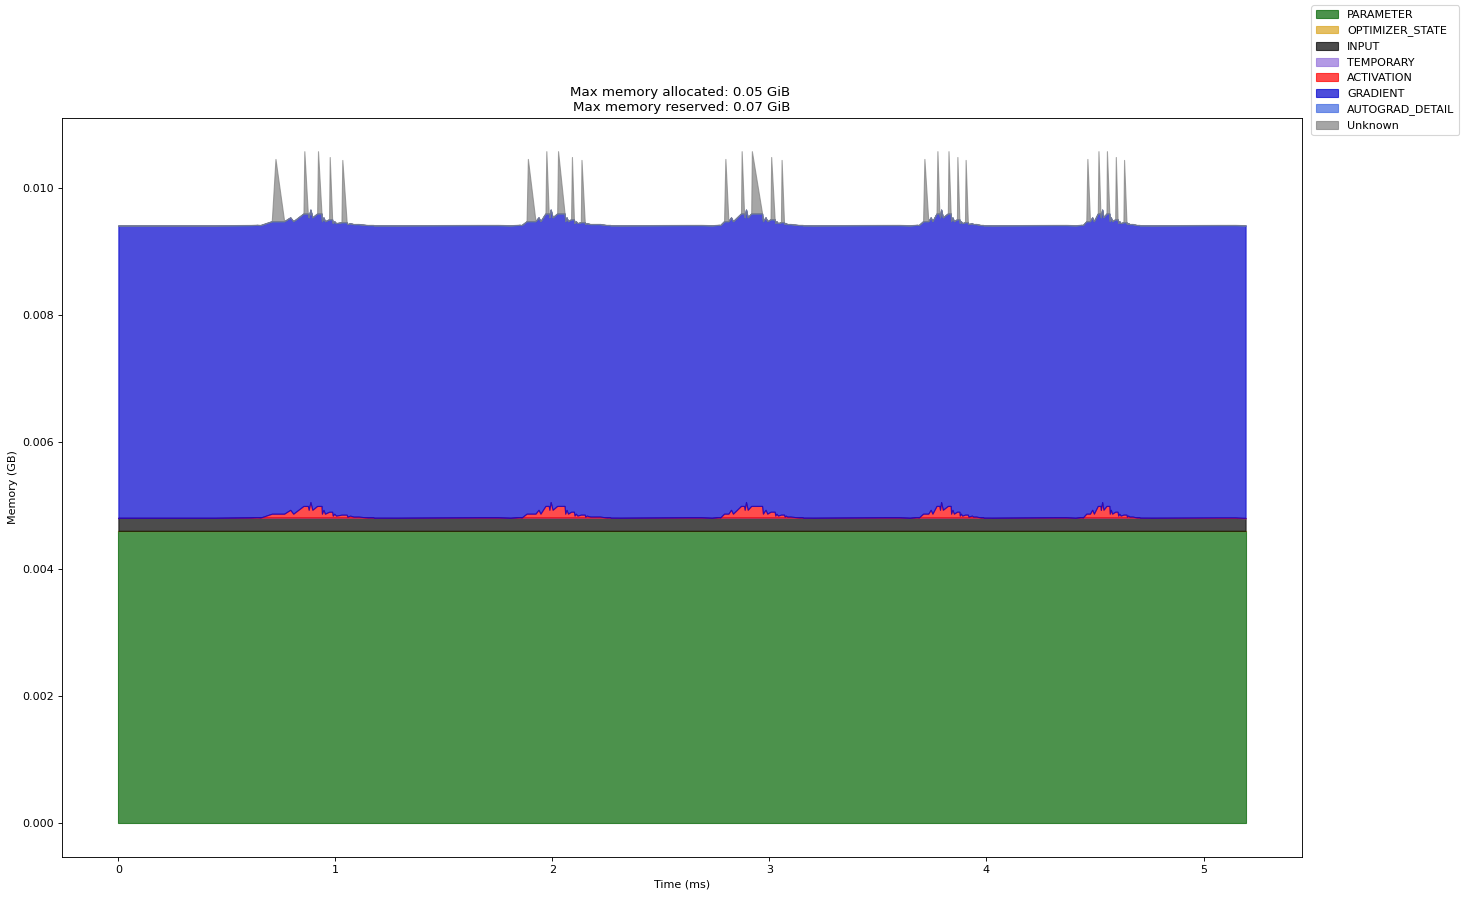

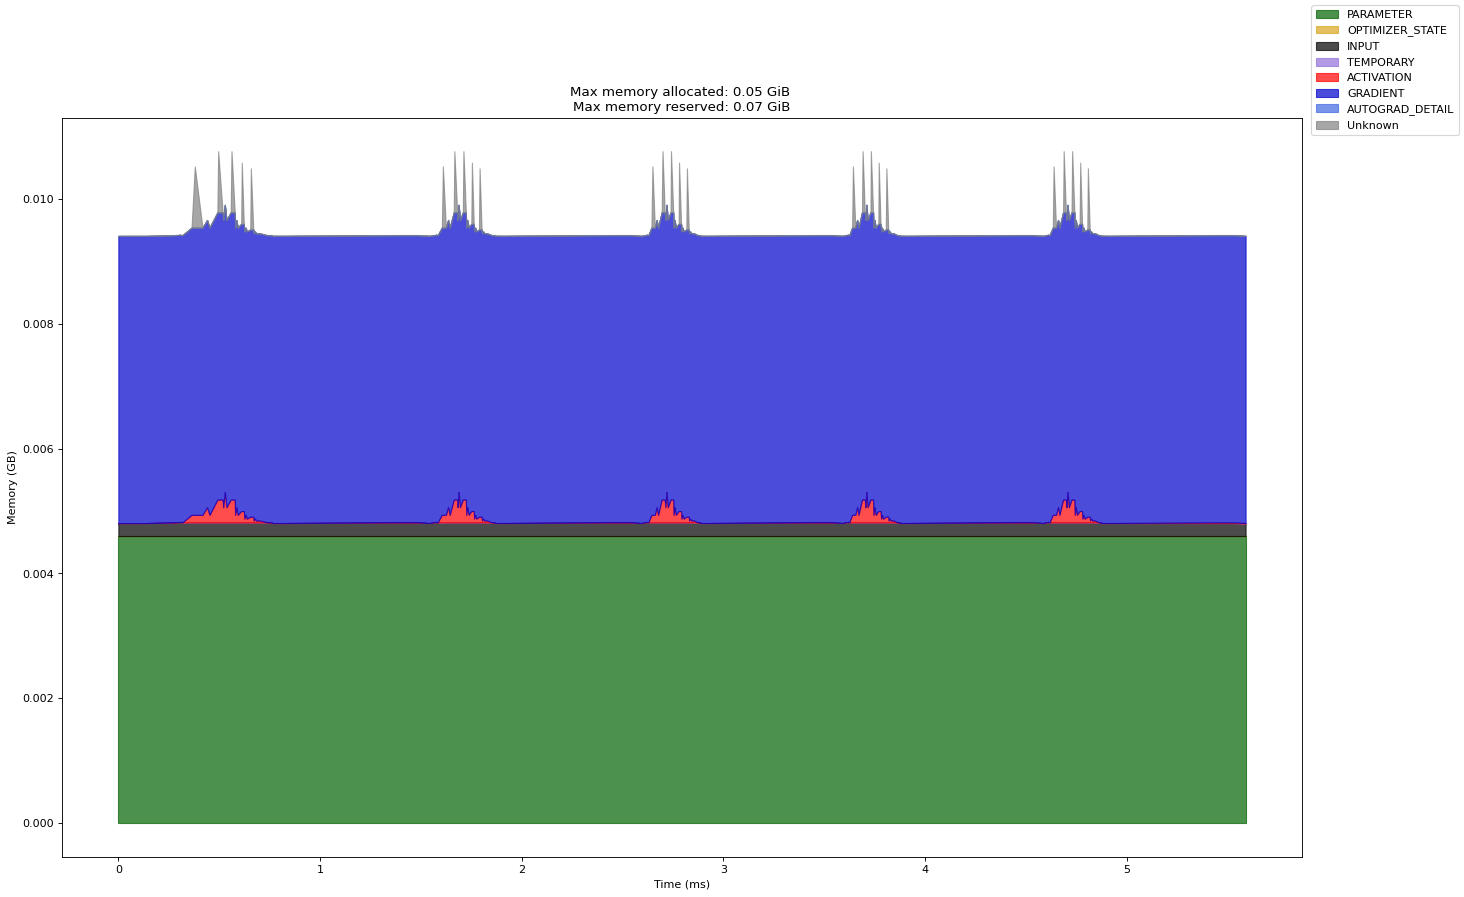

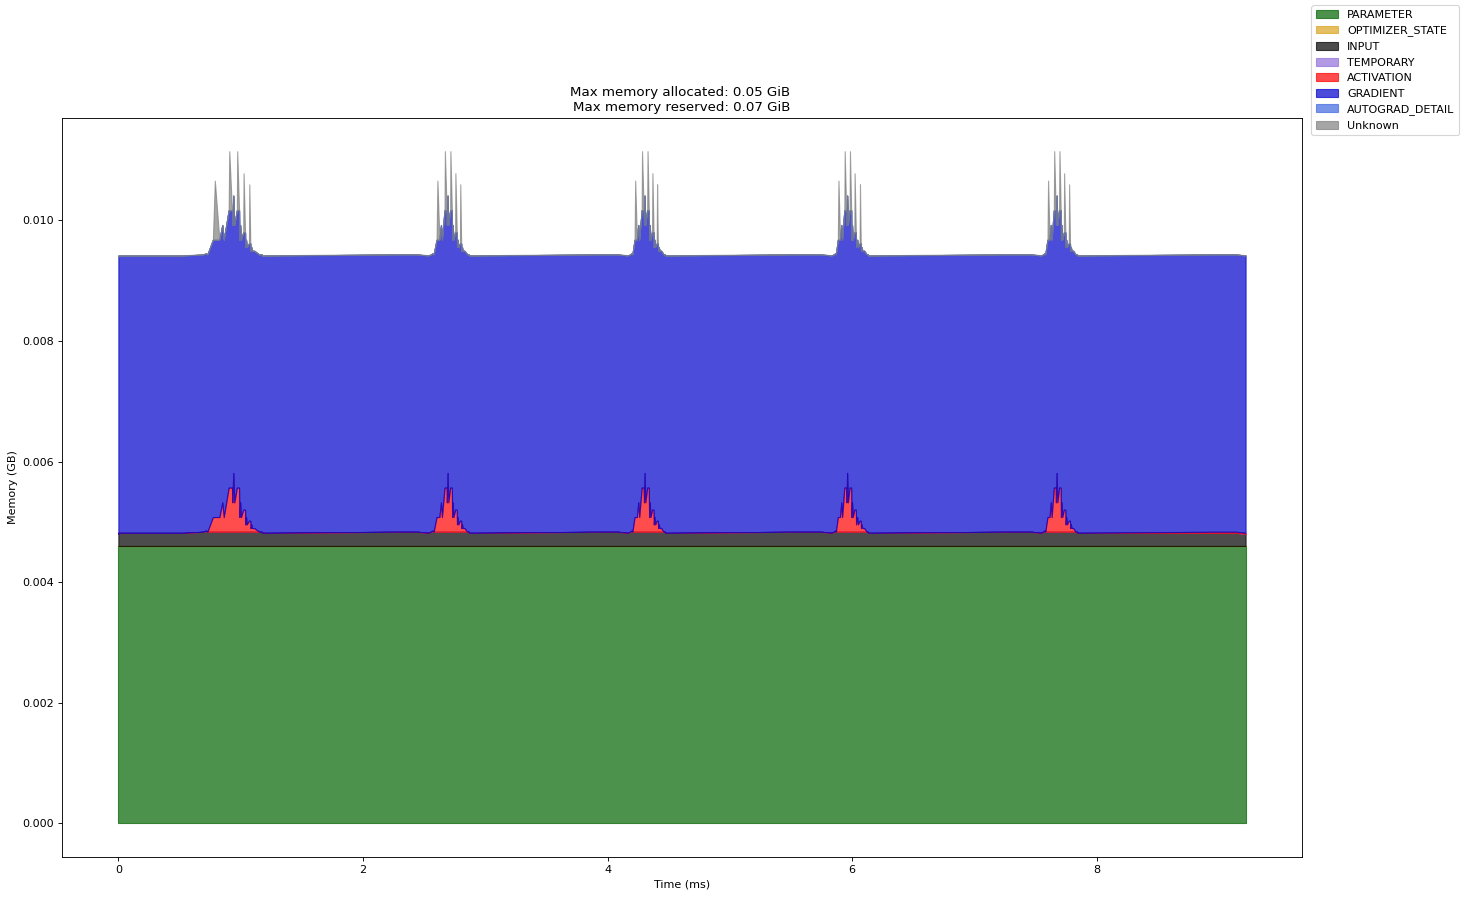

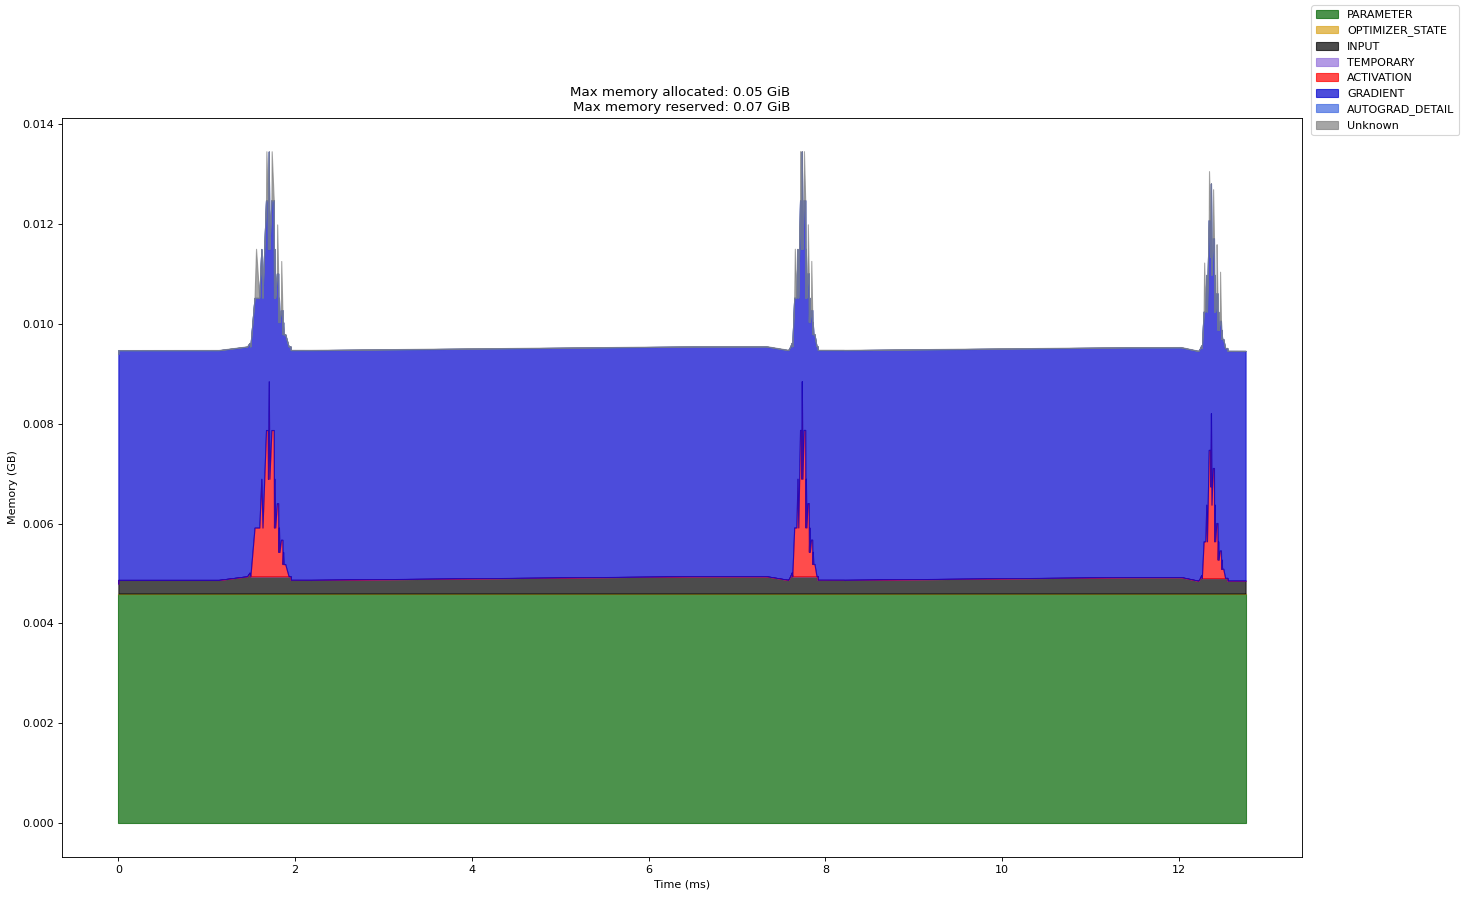

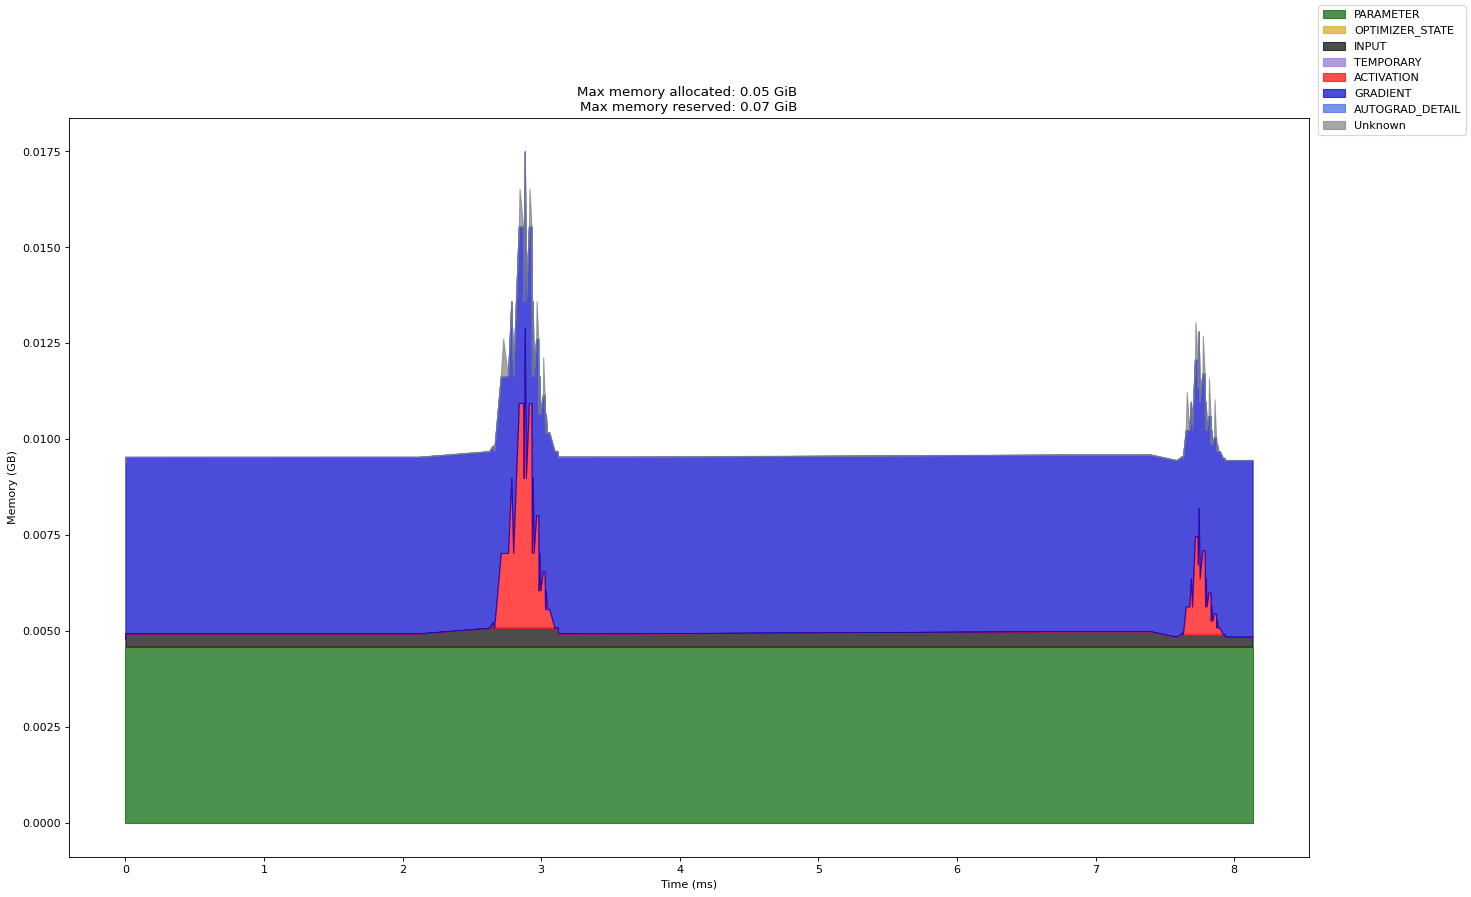

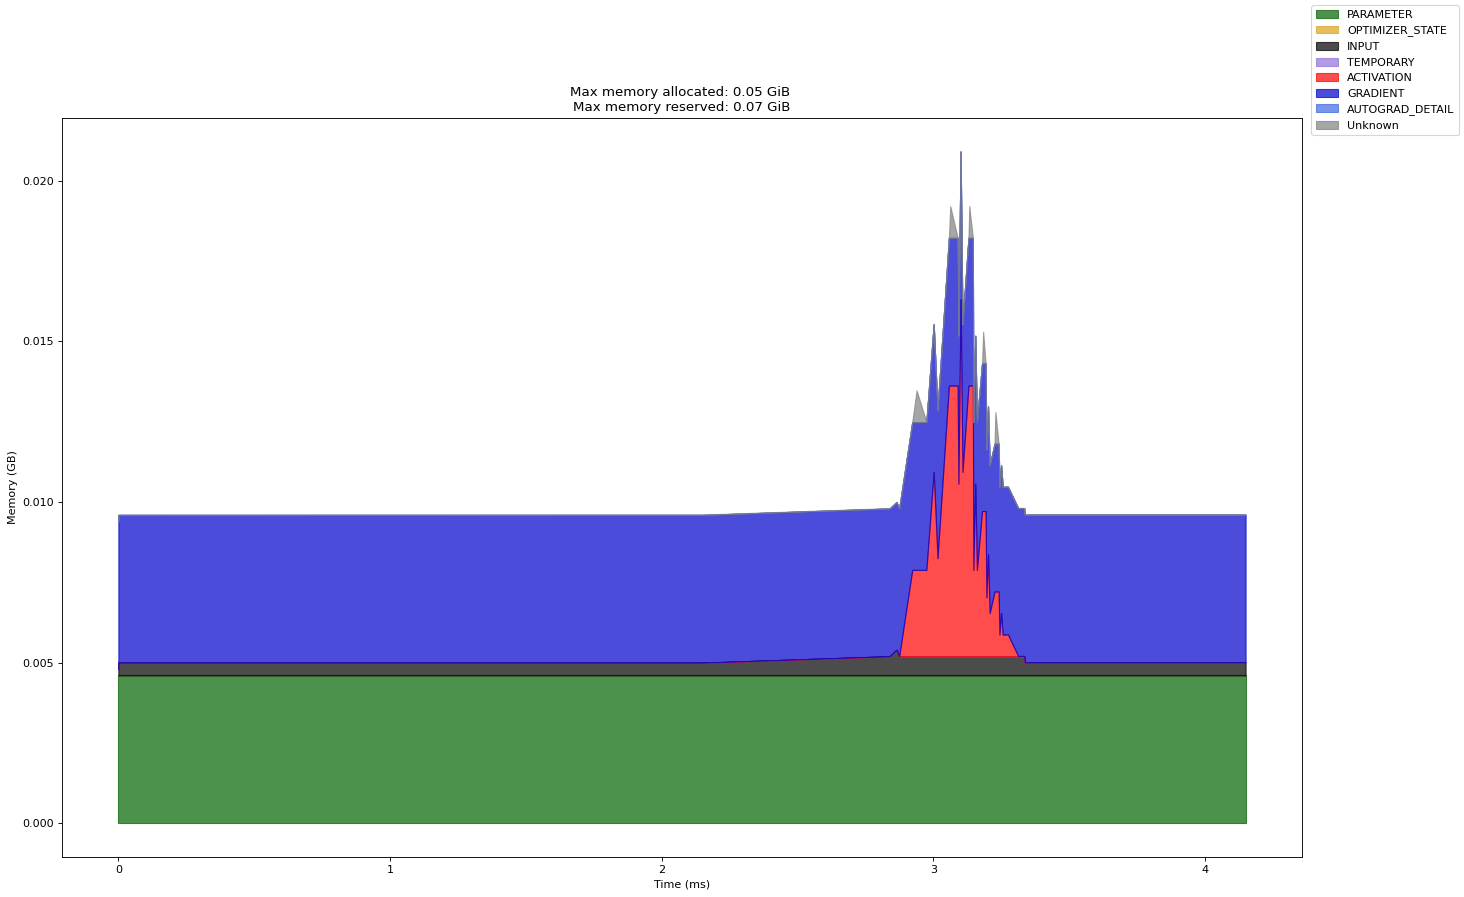

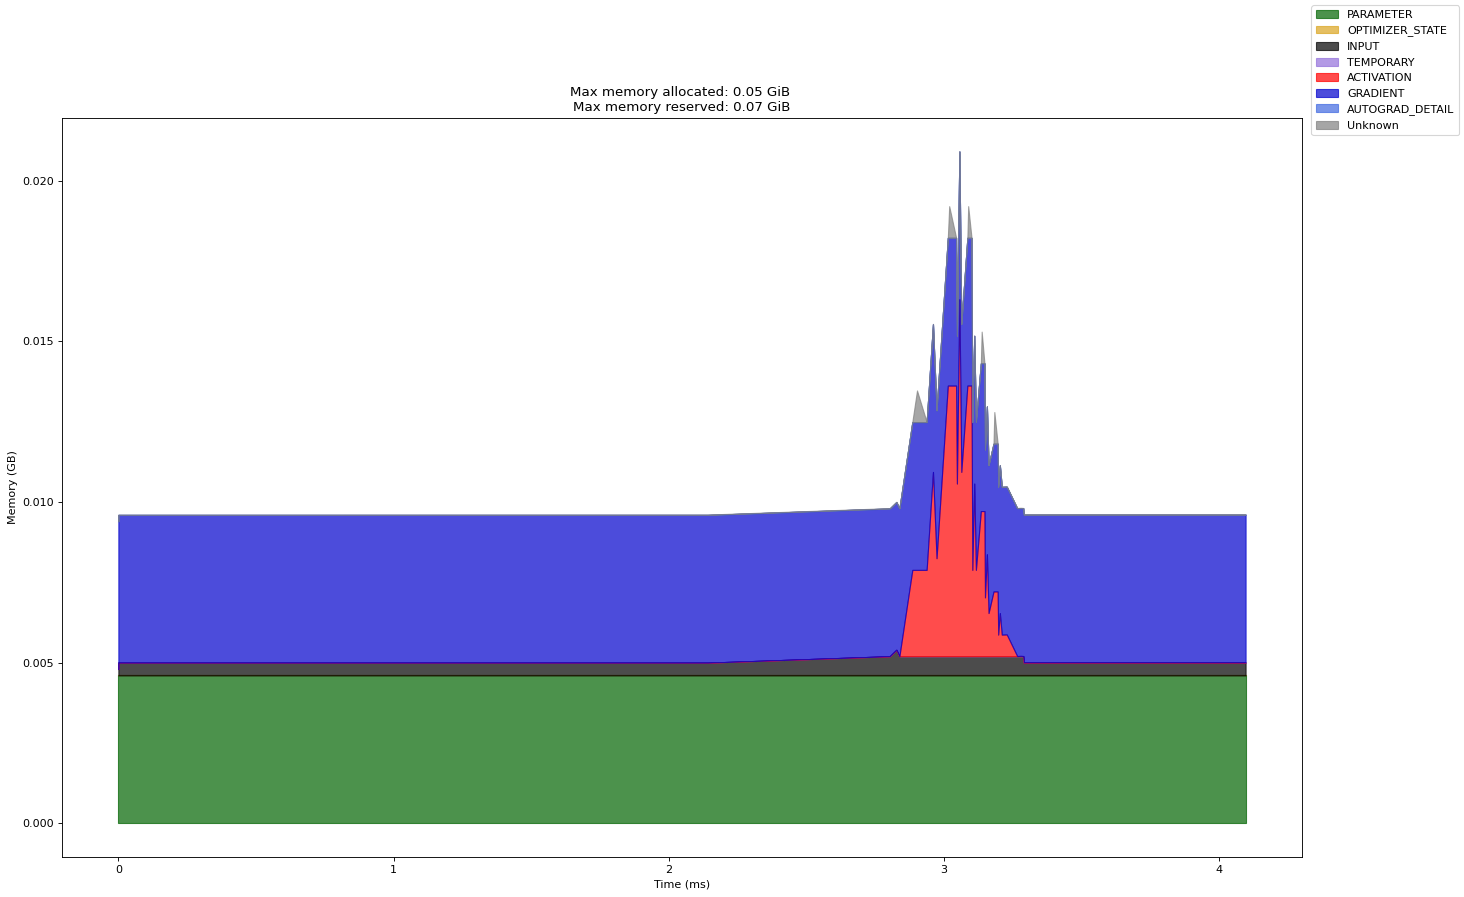

In [23]:
print("batch_sizes = ", batch_sizes)
for batch_size in batch_sizes:
    print("\ni) Running Pytorch profiler , ii) generating tensor board logs, ii) memory timeline for batch size = ", batch_size)
    profiler_result = profile_model_performance(model, test_dataloaders[batch_size])
    print("COMPLETED: i) Running Pytorch profiler , ii) generating tensor board logs, ii) memory timeline for batch size = ", batch_size)
    print("\n")

## Conclusion

In this exercise, you've learned how to diagnose and optimize AI model performance using a systematic, multi-layered profiling approach. Specifically, you have explored how to:

- **Use PyTorch Profiler to identify performance bottlenecks** at both system and operation levels
- **Monitor GPU utilization with pynvml** to understand hardware resource usage and detect under-utilization patterns
- **Analyze timeline data** to find CPU-GPU synchronization issues and kernel launch overhead
- **Conduct layer-by-layer performance analysis** to identify architectural inefficiencies within model execution
- **Prioritize compound optimization opportunities** by distinguishing between macro-level (system) and micro-level (model) bottlenecks
- **Apply systematic performance measurement** to validate which optimizations deliver the greatest impact


These profiling skills directly translate to production scenarios where models perform differently than expected. **The key insight**: production performance problems are often compound issues requiring multiple optimization strategies, with clear prioritization based on profiling evidence rather than assumptions.

The next time your model is slower than expected in production, you'll know exactly how to systematically diagnose both system-level and model-level inefficiencies, then prioritize fixes based on actual performance impact!

**Bonus exploration ideas**:

- Mixed precision profiling: Enable automatic mixed precision (AMP) and profile the performance/memory improvements
- Memory timeline exploration: Use [`export_memory_timeline()`](https://docs.pytorch.org/docs/stable/profiler.html#torch.profiler._KinetoProfile.export_memory_timeline) to spot fragmentation or memory leaks.
- Batch size optimization: Find the optimal batch size for your specific model architecture